In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import arch.unitroot as au
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.ardl import ARDL, ardl_select_order
import sys
import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import itertools
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.tsa.x13 import x13_arima_analysis
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, globalenv
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
import rpy2.rinterface_lib.callbacks
import os
import pickle
from statsmodels.tsa.x13 import x13_arima_analysis
import tempfile
import uuid
from typing import Dict, List, Tuple
import re

In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
households_structure = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')
pickle_filename = 'region_cluster_dataset.pkl'
df_roisfix = pd.read_excel('roisfix.xlsx') # скорректированный ROISFIX из Тейлора
df_roisfix = df_roisfix.drop(columns=['Unnamed: 0'])
with open(pickle_filename, 'rb') as f:
    df_region_cluster = pickle.load(f)

In [3]:
df_region_cluster.head()

,Region,Cluster_1,Cluster_2
0,Алтайский край,1,0
1,Амурская область,0,1
2,Архангельская область,1,0
3,Астраханская область,1,0
4,Белгородская область,0,0


In [4]:
df_roisfix.head()

,Date,d_ln_ROISFIX
0,2019-03-01,-0.005307
1,2019-04-01,0.002428
2,2019-05-01,0.000728
3,2019-06-01,-0.014620
4,2019-07-01,-0.024679


In [5]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [6]:
df_reg.head()

,Num_reg,Region,Date,D_top5_rozn,Cred_nagr,Zakred,Zadolg_Fl,Zadolg_Mort,Zadolg_ConsCred,Zadolg_Fl_mom,...,New_Loans_Progr_DOMRF_mom,New_Loans_Progr_mom,Int_Rate_FL,Int_Rate_Mort,Int_Rate_ConsCred,Int_Rate_Progr_DOMRF,Int_Rate_Progr,Fin_Dostup,LTV_proksi,Credit_impulse
0,1,Белгородская область,2019-02-01,0.720458,0.327789,45.661946,1.252168e+08,43448108.04,81768732.08,1.008396,...,NaN,NaN,13.637133,9.822596,14.919927,5.714816,NaN,24.878034,0.727030,-2.177079
1,1,Белгородская область,2019-03-01,0.721863,0.332653,46.108548,1.268473e+08,44177731.36,82669591.94,1.302566,...,-50.982514,NaN,13.764491,10.119091,15.090566,5.688207,NaN,25.004848,0.674074,0.715653
2,1,Белгородская область,2019-04-01,0.724760,0.336535,46.483680,1.288264e+08,44889934.26,83936427.82,1.561441,...,-65.329715,NaN,13.988365,10.431156,15.022465,5.503984,NaN,24.937820,0.347733,1.734442
3,1,Белгородская область,2019-05-01,0.724868,0.341271,47.069180,1.315857e+08,45651657.65,85934076.07,2.141982,...,220.452622,NaN,13.975779,10.629171,14.943737,5.496568,NaN,24.870805,0.677991,2.897391
4,1,Белгородская область,2019-06-01,0.724590,0.342186,47.580388,1.339479e+08,46227839.22,87720098.33,1.794755,...,40.154704,NaN,14.197338,10.697008,15.138499,5.278560,NaN,24.803802,0.655120,2.214858


In [7]:
df_RF.head()

,Num_reg,Region,Date,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,Nominal_Percent_Rate,Ent_conf_ind_mining,Ent_conf_ind_manufactoring,Covid_dum,Sank_dum,MIACR
0,0,РОССИЯ,2019-02-01,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,6.5,0,-2,0,0,7.59
1,0,РОССИЯ,2019-03-01,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,6.5,1,-2,0,0,7.68
2,0,РОССИЯ,2019-04-01,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,6.5,3,-2,0,0,7.75
3,0,РОССИЯ,2019-05-01,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,6.5,1,-1,0,0,7.72
4,0,РОССИЯ,2019-06-01,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,6.5,1,-1,0,0,7.58


In [8]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_shocks = pickle.load(f)
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

df_reg['Date'] = pd.to_datetime(df_reg['Date'])

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_rf_extra = df_RF[['Date', 'Bonds_Rate_Correct_5Y', 'Inflation_Expectations', 'exc_rate', 'MIACR', 'Covid_dum', 'Sank_dum']].copy()
df_roisf = df_roisfix[['Date', 'd_ln_ROISFIX']]
df_rf_extra = df_rf_extra.merge(df_roisf, on='Date', how='left')
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)

# Создаем лаги
df_reg['Int_Rate_FL_lag1'] = df_reg.groupby('Region')['Int_Rate_FL'].shift(1)
df_reg['Int_Rate_Mort_lag1'] = df_reg.groupby('Region')['Int_Rate_Mort'].shift(1)
df_reg['Int_Rate_ConsCred_lag1'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].shift(1)

# СПИСОК ПЕРЕМЕННЫХ
initial_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

df_reg_analys = df_reg[['Region', 'Date'] + initial_vars].copy()
df_reg_analys = df_reg_analys[df_reg_analys['Region'] != 'Москва']
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

In [9]:
df_reg_analys.head()

,Region,Date,Int_Rate_FL,Int_Rate_FL_lag1,Int_Rate_Mort,Credit_impulse,Int_Rate_Mort_lag1,Int_Rate_ConsCred,Int_Rate_ConsCred_lag1,Cred_nagr,...,Exc_rate,Inflation_Expectations,Bonds_Rate_Correct_5Y,Cluster_1,Cluster_2,New_Loans_Progr,MIACR,Covid_dum,Sank_dum,d_ln_ROISFIX
2,Белгородская область,2019-04-01,13.988365,13.764491,10.431156,1.734442,10.119091,15.022465,15.090566,0.336535,...,64.603105,9.004132,0.316818,0,0,NaN,7.75,0,0,0.002428
3,Белгородская область,2019-05-01,13.975779,13.988365,10.629171,2.897391,10.431156,14.943737,15.022465,0.341271,...,64.818706,9.416996,0.295714,0,0,NaN,7.72,0,0,0.000728
4,Белгородская область,2019-06-01,14.197338,13.975779,10.697008,2.214858,10.629171,15.138499,14.943737,0.342186,...,64.169050,9.280142,0.197895,0,0,NaN,7.58,0,0,-0.014620
5,Белгородская область,2019-07-01,13.855339,14.197338,10.354990,0.904920,10.697008,14.936965,15.138499,0.343333,...,63.222682,9.344961,0.210870,0,0,NaN,7.32,0,0,-0.024679
6,Белгородская область,2019-08-01,13.853486,13.855339,10.204734,1.584402,10.354990,14.889971,14.936965,0.345571,...,65.587483,9.304511,0.270000,0,0,NaN,7.13,0,0,-0.029715


In [10]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6545 entries, 2 to 6882
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Region                  6545 non-null   object        
 1   Date                    6545 non-null   datetime64[ns]
 2   Int_Rate_FL             6545 non-null   float64       
 3   Int_Rate_FL_lag1        6545 non-null   float64       
 4   Int_Rate_Mort           6545 non-null   float64       
 5   Credit_impulse          6545 non-null   float64       
 6   Int_Rate_Mort_lag1      6545 non-null   float64       
 7   Int_Rate_ConsCred       6545 non-null   float64       
 8   Int_Rate_ConsCred_lag1  6545 non-null   float64       
 9   Cred_nagr               6545 non-null   float64       
 10  D_top5_rozn             6545 non-null   float64       
 11  Fin_Dostup              6545 non-null   float64       
 12  Cred_structure          6545 non-null   float64      

In [11]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'
]


def detect_outlier_regions_iqr(df, key_vars, min_obs=60, max_na_pct=0.3):
    """
    Определение выбросов по IQR (межквартильный размах)
    """
    region_stats = []
    
    for region in df['Region'].unique():
        reg_data = df[df['Region'] == region][key_vars].dropna()
        
        # 1. Минимум наблюдений
        n_obs = len(reg_data)
        if n_obs < min_obs:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'Reason': f'Мало данных (<{min_obs})',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 2. % пропусков
        total_rows = len(df[df['Region'] == region])
        na_pct = 1 - (n_obs / total_rows)
        if na_pct > max_na_pct:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'NA_pct': f'{na_pct:.1%}',
                'Reason': f'Много пропусков (>{max_na_pct*100}%)',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 3. IQR по переменным
        iqr_outliers = []
        for col in key_vars:
            if col in reg_data.columns:
                data = reg_data[col].dropna()
                if len(data) > 0:
                    Q1 = data.quantile(0.15)
                    Q3 = data.quantile(0.85)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - 1.5 * IQR
                    upper_bound = Q3 + 1.5 * IQR
                    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
                    iqr_outliers.append(outliers)
        
        iqr_total = sum(iqr_outliers)
        iqr_pct = iqr_total / n_obs if n_obs > 0 else 0

        
        # РЕШЕНИЕ
        status = 'KEEP'
        reasons = []
        
        if iqr_pct > 0.2:  # >20% выбросов по IQR
            reasons.append(f'Много выбросов по IQR ({iqr_pct:.1%})')
            status = 'EXCLUDE'
        
        region_stats.append({
            'Region': region,
            'N_obs': n_obs,
            'NA_pct': f'{na_pct:.1%}',
            'IQR_outliers': iqr_total,
            'IQR_pct': f'{iqr_pct:.1%}',
            'Reasons': '; '.join(reasons),
            'Status': status
        })
    
    return pd.DataFrame(region_stats)

# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")





ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 85 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     77   0.0%             3    3.9%                                  KEEP
                                    Брянская область     77   0.0%             4    5.2%                                  KEEP
                                Владимирская область     77   0.0%             4    5.2%                                  KEEP
                                 Воронежская область     77   0.0%             4    5.2%                                  KEEP
                                  Ивановская область     77   0.0%             3    3.9%                                  KEEP
                                    Тверская область     77   0.0%             3    3.9%                                  KEEP
                                   Калужская область

In [12]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
descriptive_df = df_reg_analys[[
    'Int_Rate_FL',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_ConsCred',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'Covid_dum',
    'Sank_dum'
]]
desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                            Среднее     Медиана    ст. откл.     Мин.  \
Int_Rate_FL                  14.260      13.154        3.484    9.100   
Int_Rate_Mort                 8.256       8.069        1.300    3.327   
Credit_impulse               -0.637      -0.127        6.558  -59.204   
Int_Rate_ConsCred            18.067      15.928        5.660    1.306   
Cred_nagr                     0.354       0.358        0.085    0.072   
D_top5_rozn                   0.783       0.780        0.063    0.614   
Fin_Dostup                   19.190      18.622        6.043    2.972   
Cred_structure                0.468       0.471        0.065    0.151   
Def_Zadolg_Fl                 4.241       4.190        1.117    1.407   
Def_Zadolg_Mort               0.614       0.472        0.512    0.043   
Def_Zadolg_ConsCred           7.446       7.447        1.556    2.154   
Mon_Shock                    -0.008      -0.011        0.062   -0.225  

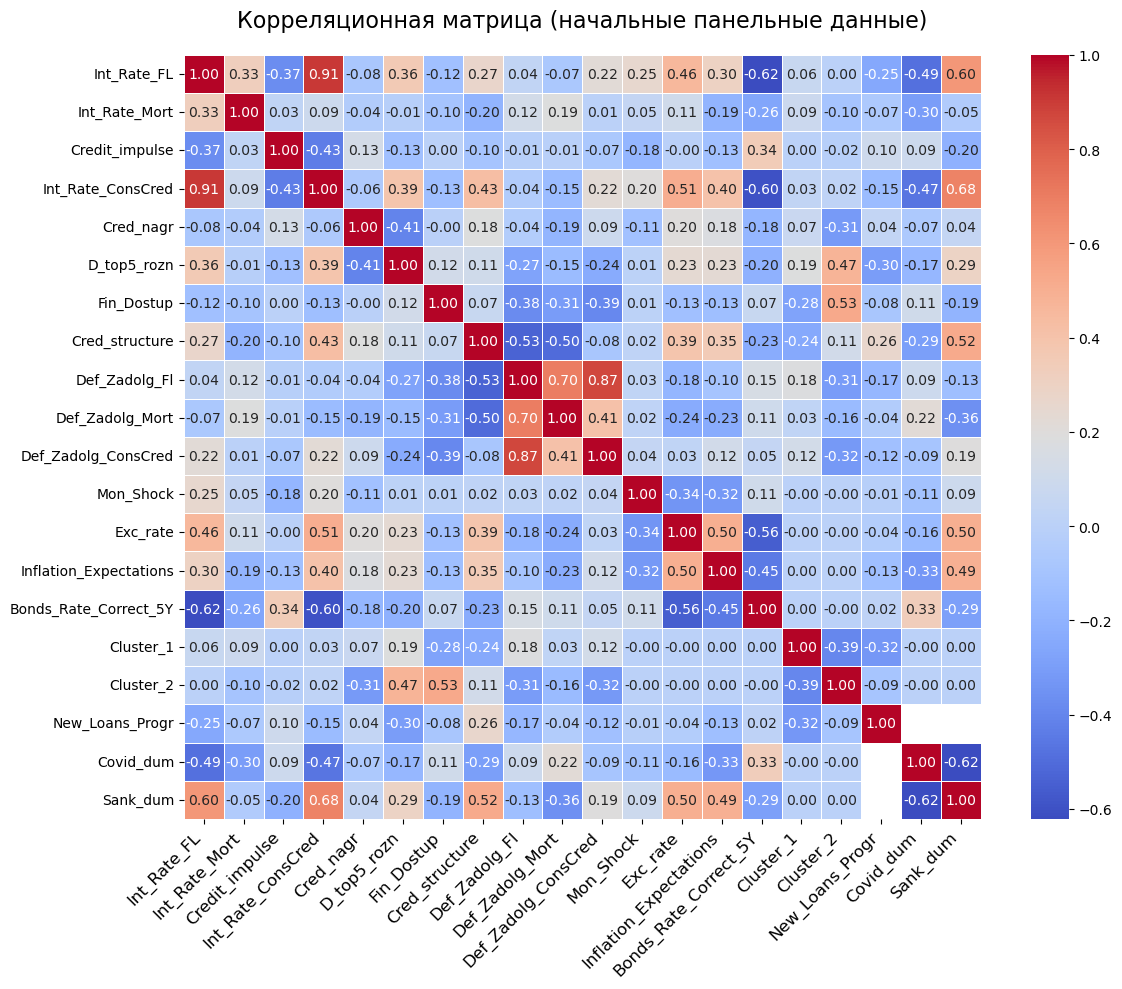

In [13]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [14]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    'Int_Rate_FL_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
              Variable      VIF
              Sank_dum 3.909364
      Int_Rate_FL_lag1 3.315739
              Exc_rate 3.112180
 Bonds_Rate_Correct_5Y 3.101013
           D_top5_rozn 2.734070
             Cluster_2 2.557236
        Cred_structure 2.343888
             Covid_dum 2.212532
         Def_Zadolg_Fl 2.183463
Inflation_Expectations 2.006068
            Fin_Dostup 1.796754
             Cred_nagr 1.766382
             Cluster_1 1.738781
             Mon_Shock 1.621344
        Credit_impulse 1.472167


In [15]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 2
###############################

vif_variables = [
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2
              Variable      VIF
              Sank_dum 4.009593
Int_Rate_ConsCred_lag1 3.960355
              Exc_rate 3.070922
 Bonds_Rate_Correct_5Y 2.960989
           D_top5_rozn 2.808705
             Cluster_2 2.551984
             Covid_dum 2.164453
Inflation_Expectations 1.942600
        Cred_structure 1.826526
             Cred_nagr 1.758109
             Cluster_1 1.743610
            Fin_Dostup 1.713609
   Def_Zadolg_ConsCred 1.678386
             Mon_Shock 1.666322
        Credit_impulse 1.510006


In [16]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 3
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3
              Variable      VIF
              Sank_dum 3.978328
              Exc_rate 3.333608
             Covid_dum 2.781886
             Cluster_2 2.505194
 Bonds_Rate_Correct_5Y 2.497052
           D_top5_rozn 2.486338
Inflation_Expectations 2.184486
        Cred_structure 1.941002
    Int_Rate_Mort_lag1 1.843891
            Fin_Dostup 1.828533
             Cluster_1 1.780653
       Def_Zadolg_Mort 1.716979
             Cred_nagr 1.708335
             Mon_Shock 1.519761
        Credit_impulse 1.454627


In [17]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 4
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations',
    'New_Loans_Progr',
    'Cluster_1',
    'Cluster_2',
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 4
              Variable      VIF
 Bonds_Rate_Correct_5Y 3.130162
              Exc_rate 2.993310
             Cluster_2 2.646537
           D_top5_rozn 2.478757
             Cluster_1 2.023456
            Fin_Dostup 1.937992
       Def_Zadolg_Mort 1.883585
             Mon_Shock 1.851133
    Int_Rate_Mort_lag1 1.784352
Inflation_Expectations 1.773966
             Cred_nagr 1.741870
        Credit_impulse 1.720946
        Cred_structure 1.478392
       New_Loans_Progr 1.306184


In [18]:
##############################
# Тест Фридмана на сезонность
##############################

variables_for_analysis = [
    ('MIACR', 'Cтавка по межбанковским кредитам (MIACR)')    
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [19]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                                Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Cтавка по межбанковским кредитам (MIACR)     3.774737 0.976049            False        5        12


In [20]:
#New_Loans_Progr
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6083 entries, 2 to 6882
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Region                  6083 non-null   object        
 1   Date                    6083 non-null   datetime64[ns]
 2   Int_Rate_FL             6083 non-null   float64       
 3   Int_Rate_FL_lag1        6083 non-null   float64       
 4   Int_Rate_Mort           6083 non-null   float64       
 5   Credit_impulse          6083 non-null   float64       
 6   Int_Rate_Mort_lag1      6083 non-null   float64       
 7   Int_Rate_ConsCred       6083 non-null   float64       
 8   Int_Rate_ConsCred_lag1  6083 non-null   float64       
 9   Cred_nagr               6083 non-null   float64       
 10  D_top5_rozn             6083 non-null   float64       
 11  Fin_Dostup              6083 non-null   float64       
 12  Cred_structure          6083 non-null   float64      


СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Курс рубля (Exc_rate):
  ✓ Успешно скорректировано, снижение волатильности: 1.7%

Инфляционные ожидания (Inflation_Expectations):
  ✓ Успешно скорректировано, снижение волатильности: 1.8%

Ставки на облигации скорректированные 5Y (Bonds_Rate_Correct_5Y):
  ✓ Успешно скорректировано, снижение волатильности: 3.6%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

Ставка на кредиты ФЛ (Int_Rate_FL):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 78/79 регионов

Ставка на кредиты ФЛ лаг (Int_Rate_FL_lag1):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 78/79 регионов

Ставка на ипотеку (Int_Rate_Mort):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 79/79 регионов

Ставка на ипотеку лаг (Int_Rate_Mort_lag1):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 77/79 регионов

Кредитный импульс (Credit_impulse):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 74/79 регионов

Ставка на потребительский кре

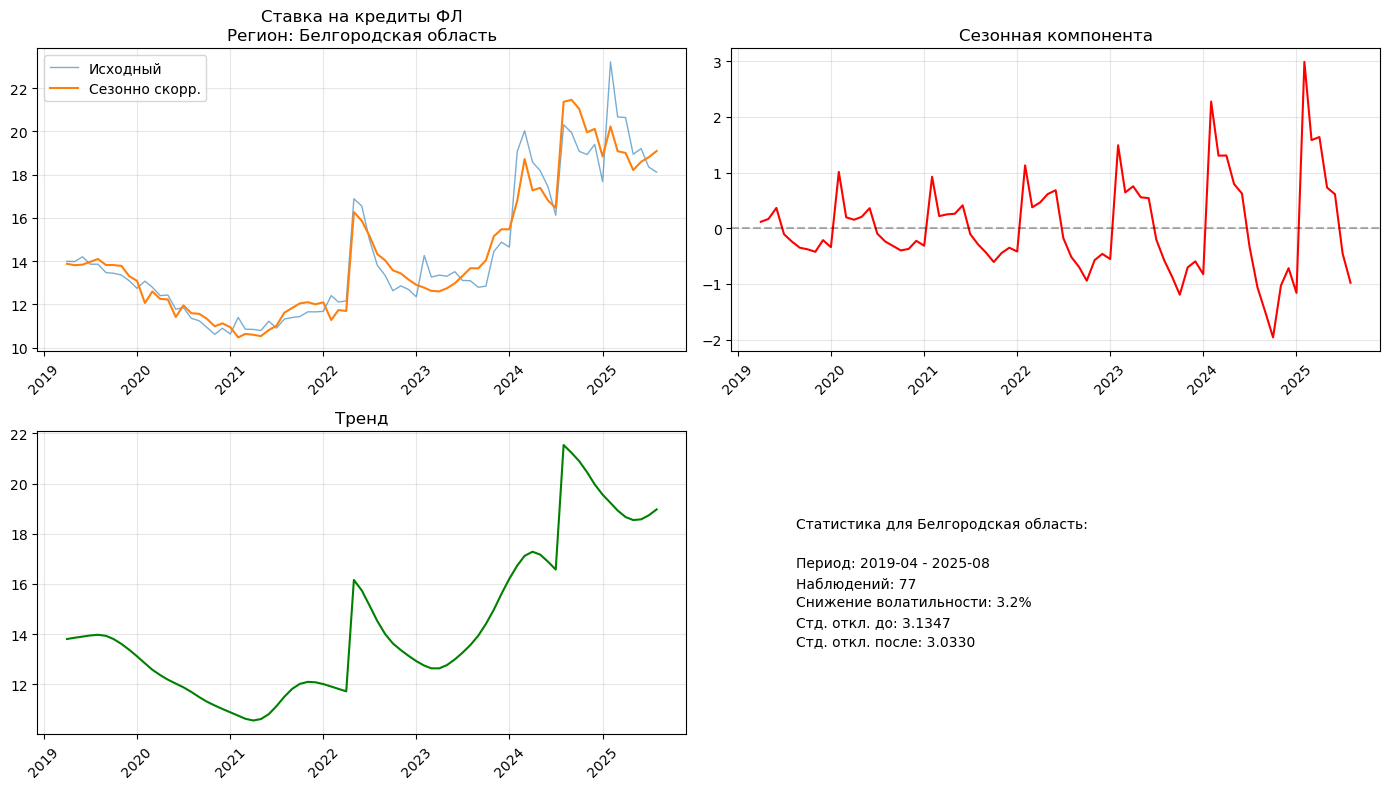

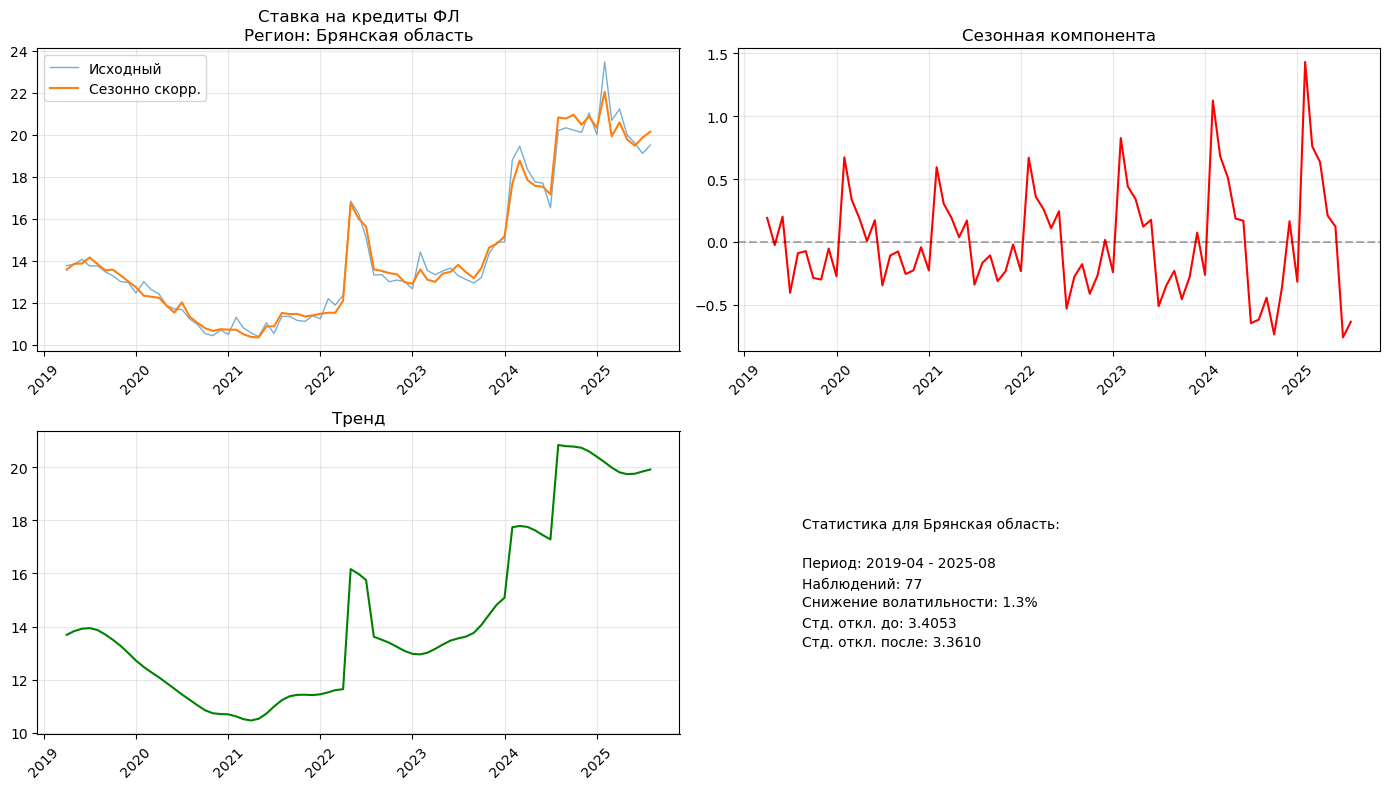

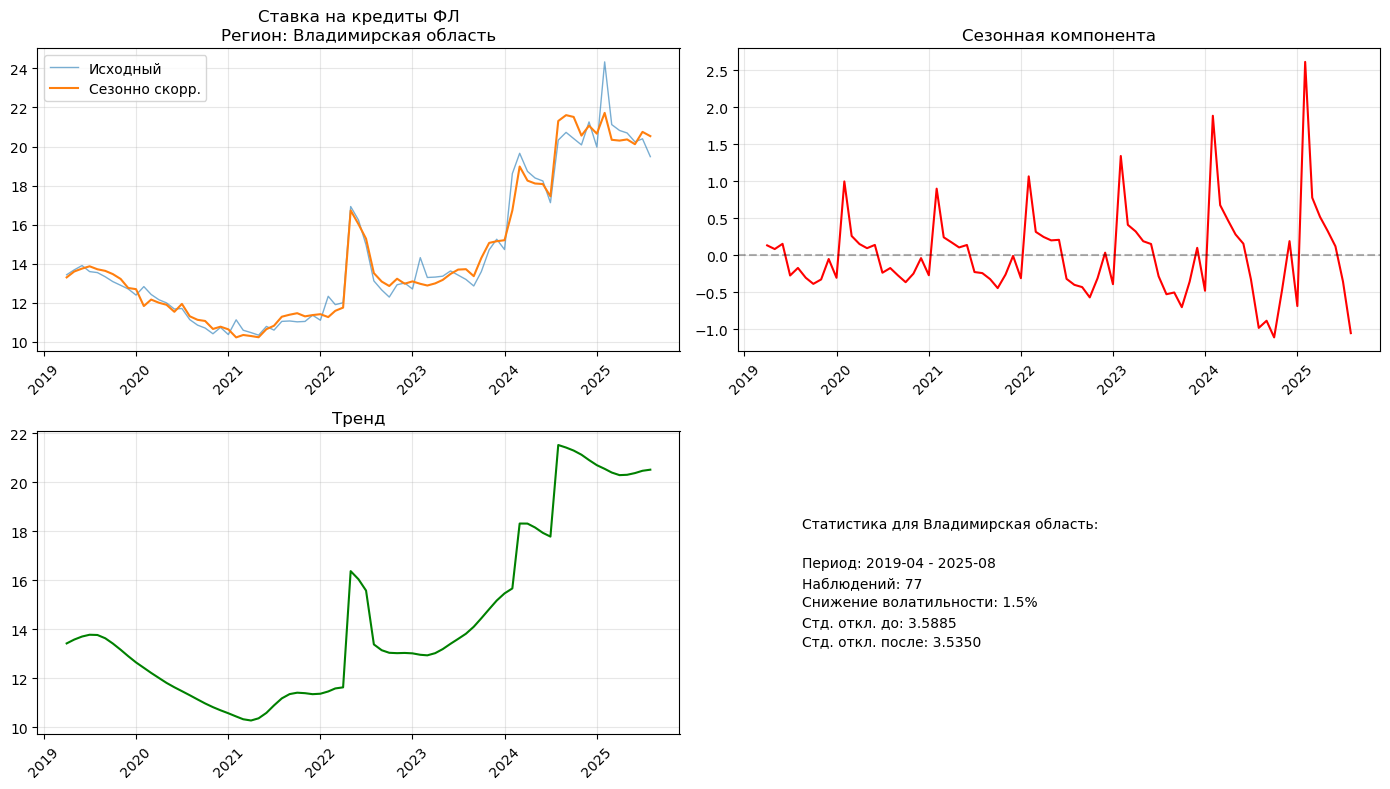

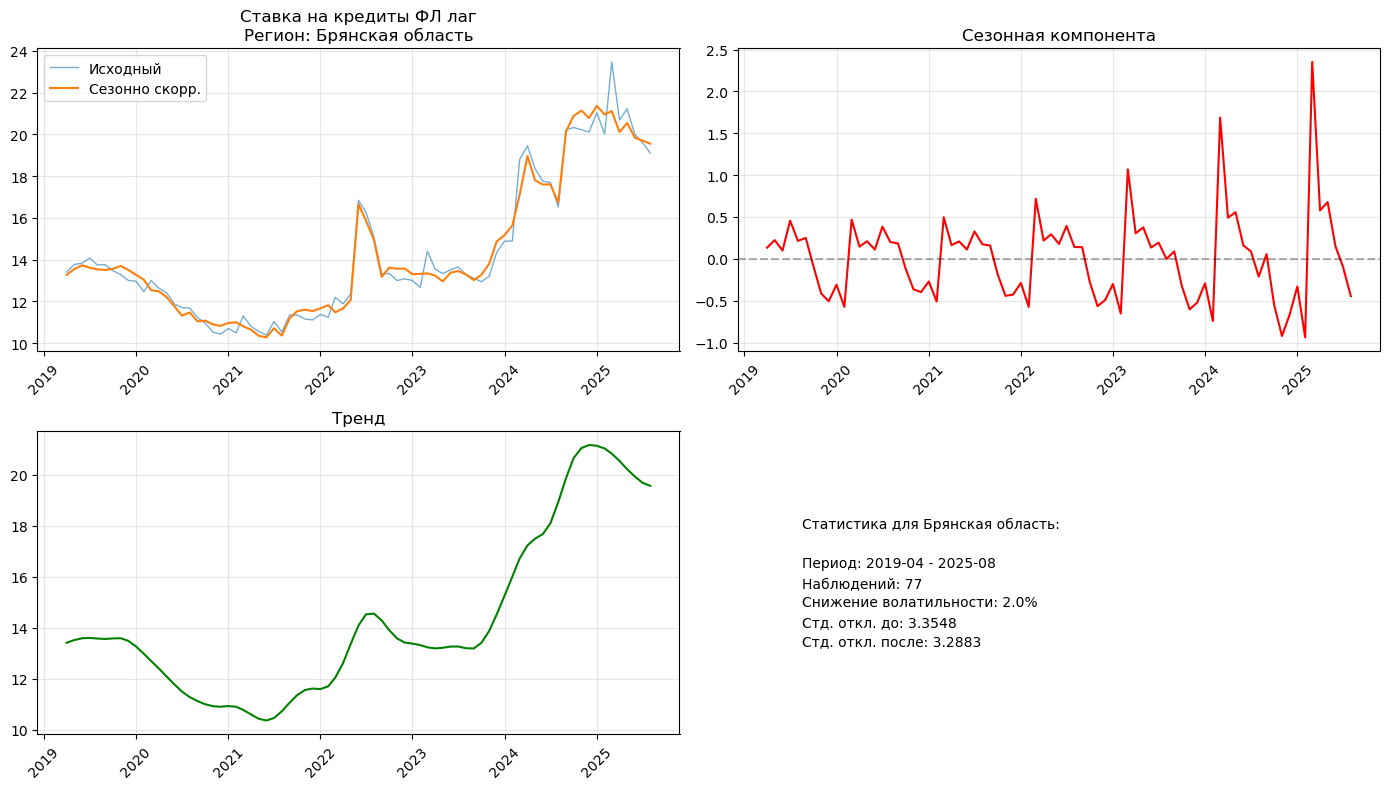

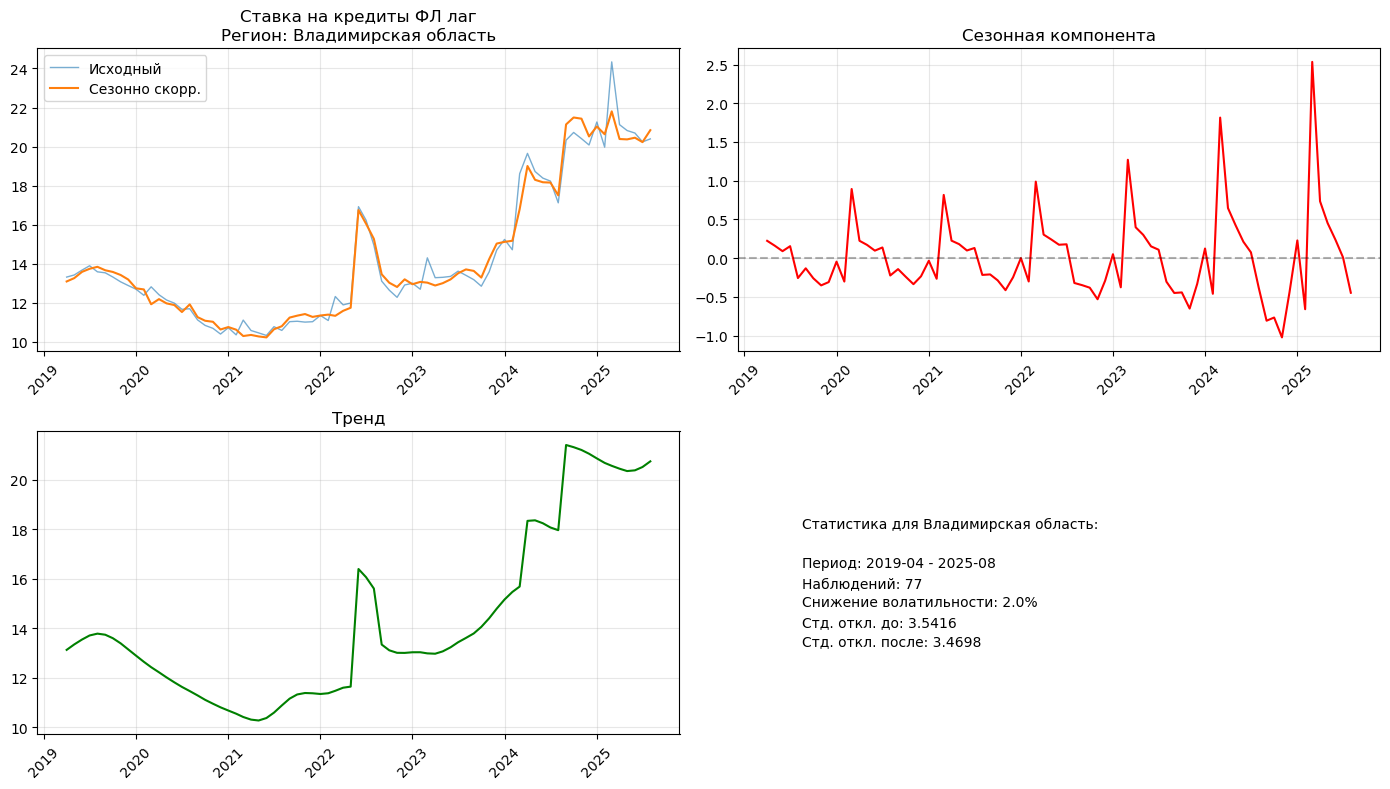


Графики федеральных переменных...


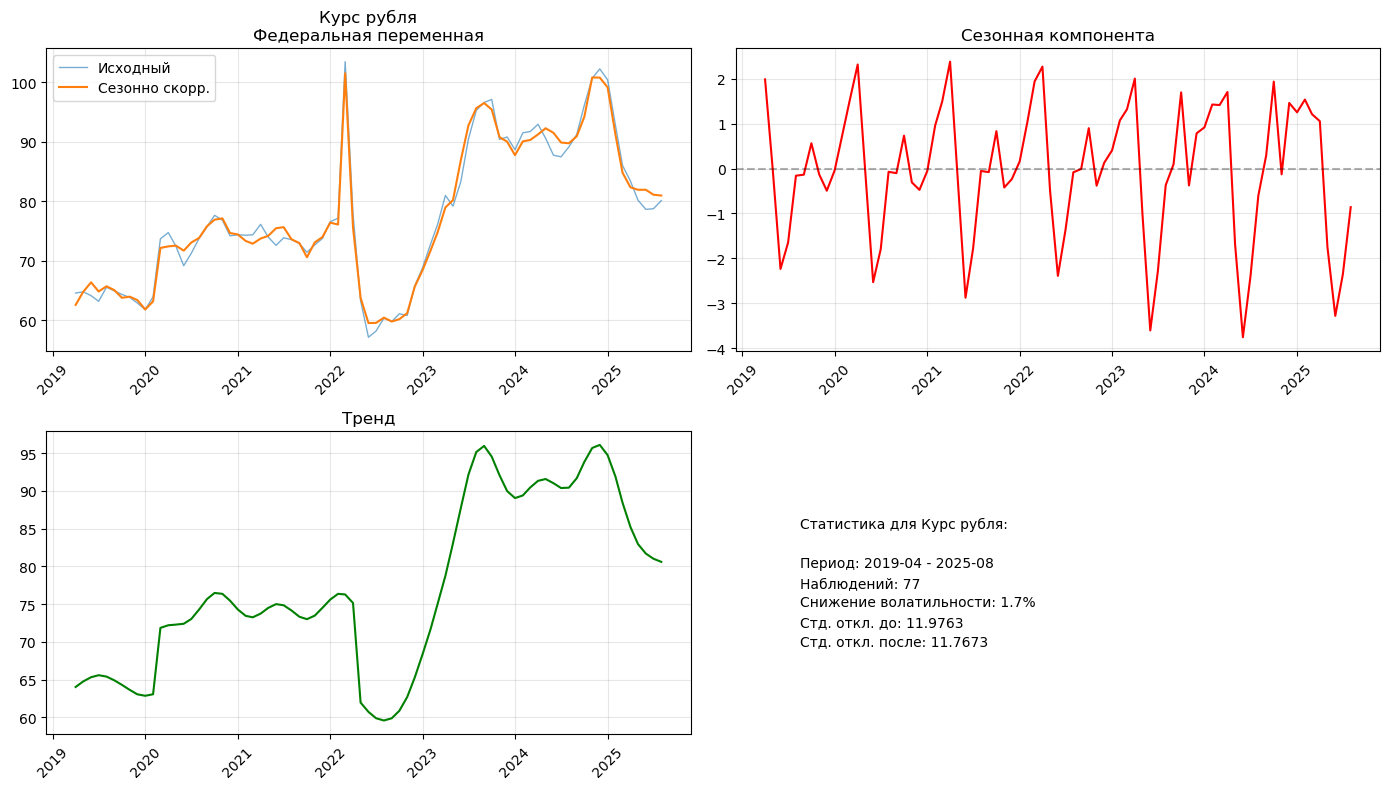

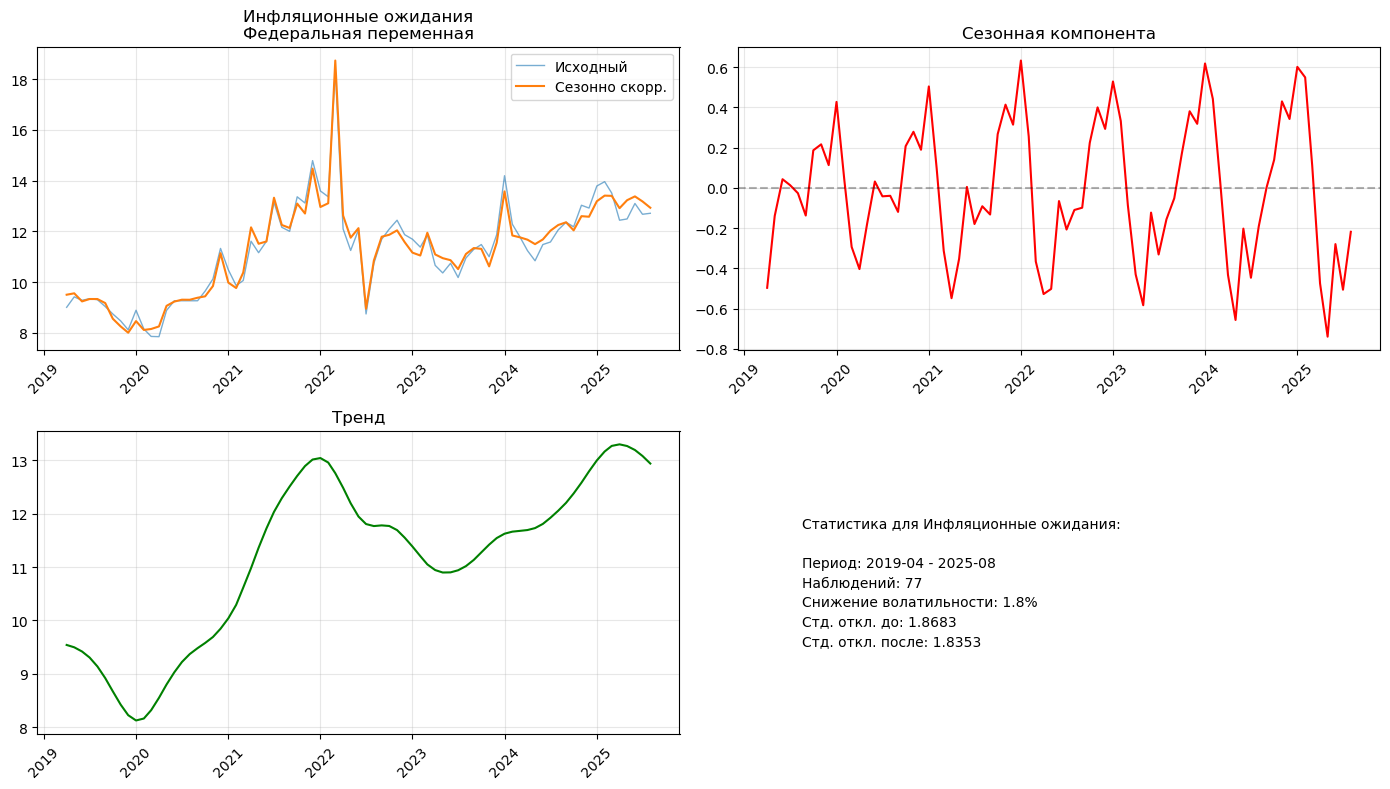

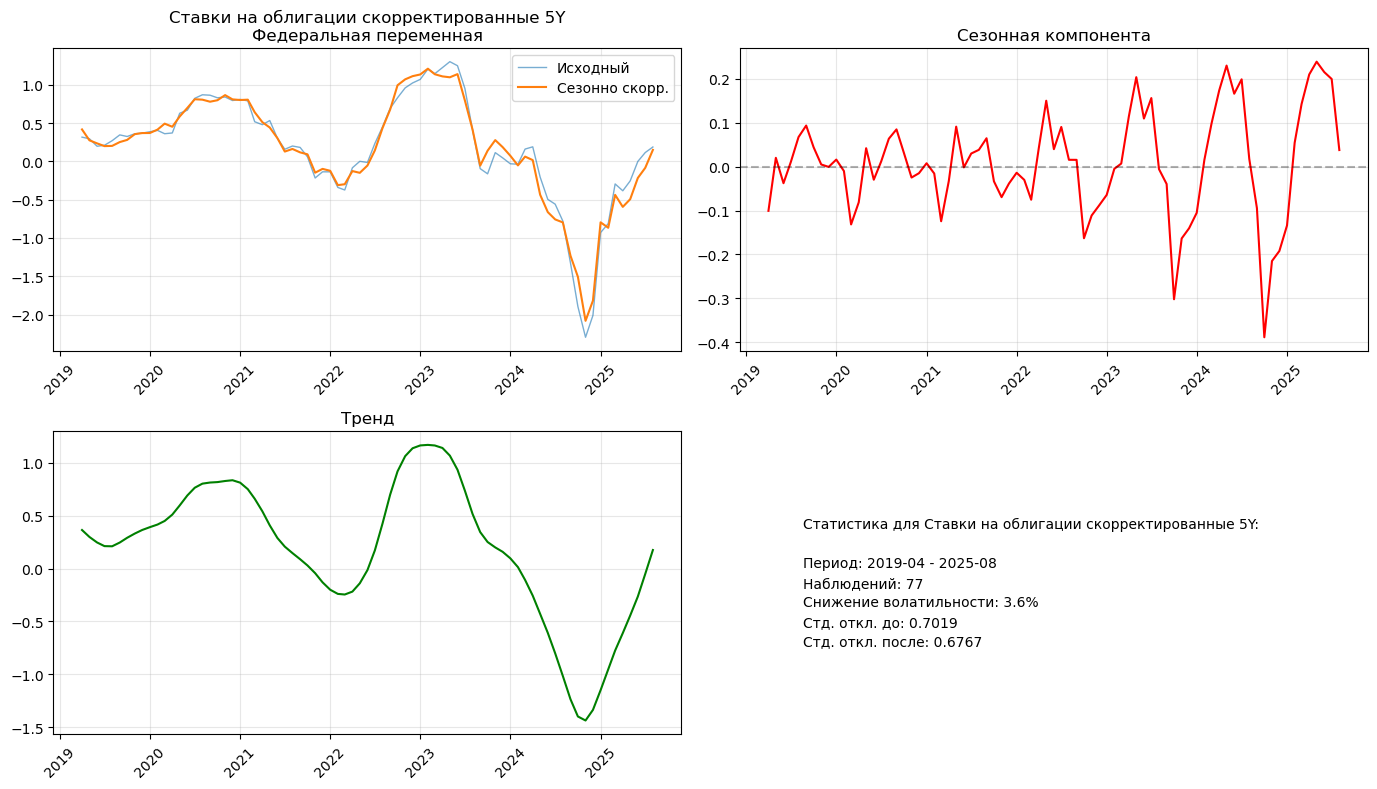


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 3/3
Обработано региональных переменных: 14/14
Общее количество добавленных столбцов: 51
Форма df_reg_analys: (6083, 78)

Столбцов _adj: 17
Столбцов _trend: 17
Столбцов _seasonal: 17

✓ Скорректированные ряды добавлены в df_reg_analys
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)


In [21]:
# ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====

# Заглушаем предупреждения
warnings.filterwarnings('ignore')

# Путь к бинарнику X-13
X13_PATH = 'C:\\Program Files (x86)\\x13as'

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Создаем папку для логов
os.makedirs("x13_logs", exist_ok=True)

# ============ ОПРЕДЕЛЕНИЕ ПЕРЕМЕННЫХ ДЛЯ КОРРЕКТИРОВКИ ============

# ФЕДЕРАЛЬНЫЕ переменные (одна серия для всех регионов)
federal_variables = {
    'Exc_rate': 'Курс рубля', 
    'Inflation_Expectations': 'Инфляционные ожидания',
    'Bonds_Rate_Correct_5Y': 'Ставки на облигации скорректированные 5Y'
}

# РЕГИОНАЛЬНЫЕ переменные (серии по каждому региону)
regional_variables = {
    'Int_Rate_FL': 'Ставка на кредиты ФЛ',
    'Int_Rate_FL_lag1' : 'Ставка на кредиты ФЛ лаг',
    'Int_Rate_Mort': 'Ставка на ипотеку',
    'Int_Rate_Mort_lag1': 'Ставка на ипотеку лаг',
    'Credit_impulse': 'Кредитный импульс',
    'Int_Rate_ConsCred': 'Ставка на потребительский кредит',
    'Int_Rate_ConsCred_lag1': 'Ставка на потребительский кредит лаг',
    'Cred_nagr': 'Кредитная нагрузка',
    'D_top5_rozn': 'Доля топ-5 банков в розничном портфеле региона',
    'Fin_Dostup':'Кол-во пунктов банковского обслуживания на 100к чел.',
    'Cred_structure':'Доля ипотечных жилищных кредитов в розничном портфеле',
    'Def_Zadolg_Fl':'Доля просроченной задолженности по кредитам физических лиц',
    'Def_Zadolg_Mort':'Доля просроченной задолженности по ипотечным жилищным кредитам',
    'Def_Zadolg_ConsCred':'Доля просроченной задолженности по потребительским кредитам'
    
}
# ============ ФУНКЦИЯ ДЛЯ СЕЗОННОЙ КОРРЕКТИРОВКИ ОДНОЙ СЕРИИ ============

def seasonal_adjust_panel_series(series_data, variable_name, region_name=None, min_obs=24):
    """
    Выполнить X-13 сезонную корректировку для одной серии (панельные данные)
    
    Parameters:
    -----------
    series_data : pd.Series
        Временной ряд с DatetimeIndex
    variable_name : str
        Название переменной
    region_name : str, optional
        Название региона (для региональных переменных)
    min_obs : int
        Minimum number of observations
    
    Returns:
    --------
    dict с результатами или None при ошибке
    """
    try:
        # Проверка данных
        if len(series_data) < min_obs:
            return None
        
        # Убедиться, что индекс - DatetimeIndex
        if not isinstance(series_data.index, pd.DatetimeIndex):
            series_data.index = pd.to_datetime(series_data.index)
        
        # Установить частоту на месячную
        ts_regular = series_data.asfreq('MS').dropna()
        
        if len(ts_regular) < min_obs:
            return None
        
        # Информация о данных
        start_date = ts_regular.index[0]
        end_date = ts_regular.index[-1]
        
        # Создаем уникальную временную папку для каждого вызова X-13
        # чтобы избежать конфликтов файлов
        temp_dir = tempfile.mkdtemp(prefix=f"x13_{uuid.uuid4().hex[:8]}_")
        
        # Запуск X-13 с указанием уникальной временной директории
        try:
            res = x13_arima_analysis(
                endog=ts_regular,
                x12path=x13_dir,
                prefer_x13=True,
                outlier=True,
                trading=False,
                print_stdout=False
            )
            
            # Извлечение компонент
            adj = res.seasadj
            trend = res.trend
            seas = ts_regular - adj
            
        except Exception as e:
            # Если X-13 не сработал, попробуем без outlier
            try:
                res = x13_arima_analysis(
                    endog=ts_regular,
                    x12path=x13_dir,
                    prefer_x13=True,
                    outlier=False,  # Без определения выбросов
                    trading=False,
                    print_stdout=False
                )
                
                adj = res.seasadj
                trend = res.trend
                seas = ts_regular - adj
                
            except Exception as e2:
                # Если все еще не работает, пропускаем
                return None
        
        # Расчёт эффективности
        original_std = ts_regular.std()
        adj_std = adj.std()
        reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
        
        # Удаляем временную директорию
        try:
            import shutil
            shutil.rmtree(temp_dir, ignore_errors=True)
        except:
            pass
        
        return {
            'dates': ts_regular.index,
            'adj': adj.values,
            'trend': trend.values,
            'seasonal': seas.values,
            'reduction': reduction
        }
        
    except Exception as e:
        # Подавляем вывод ошибок
        return None

# ============ ОБРАБОТКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

federal_adjusted = {}

for col, name in federal_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Для федеральных переменных берем уникальные значения по датам
    fed_data = df_reg_analys[['Date', col]].copy().dropna()
    
    if len(fed_data) == 0:
        print(f"  ✗ Нет данных. Пропуск.")
        continue
    
    # Убедиться, что одно значение на дату
    fed_data = fed_data.drop_duplicates('Date')
    fed_data = fed_data.set_index('Date')[col].sort_index()
    
    # Сезонная корректировка
    result = seasonal_adjust_panel_series(fed_data, col, region_name=None)
    
    if result is not None:
        federal_adjusted[col] = result
        print(f"  ✓ Успешно скорректировано, снижение волатильности: {result['reduction']:.1f}%")
        
        # Добавляем результаты обратно в df_reg_analys
        for date, adj_val, trend_val, seas_val in zip(
            result['dates'], result['adj'], result['trend'], result['seasonal']
        ):
            mask = df_reg_analys['Date'] == date
            df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
            df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
            df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    else:
        print(f"  ✗ Не удалось скорректировать")

# ============ ОБРАБОТКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

regional_adjusted = {}

for col, name in regional_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Получаем список регионов
    regions = df_reg_analys['Region'].unique()
    print(f"  Обрабатываю {len(regions)} регионов...")
    
    regional_adjusted[col] = {}
    successful_regions = 0
    
    for region in regions:
        # Фильтруем данные по региону
        region_data = df_reg_analys[df_reg_analys['Region'] == region][['Date', col]].copy().dropna()
        
        if len(region_data) < 24:
            continue  # Пропускаем регионы с недостаточным количеством данных
        
        # Подготавливаем временной ряд
        region_series = region_data.set_index('Date')[col].sort_index()
        
        # Сезонная корректировка
        result = seasonal_adjust_panel_series(region_series, col, region_name=region, min_obs=24)
        
        if result is not None:
            regional_adjusted[col][region] = result
            successful_regions += 1
            
            # Добавляем результаты в df_reg_analys
            for date, adj_val, trend_val, seas_val in zip(
                result['dates'], result['adj'], result['trend'], result['seasonal']
            ):
                mask = (df_reg_analys['Region'] == region) & (df_reg_analys['Date'] == date)
                if mask.any():
                    df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
                    df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
                    df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    
    print(f"  ✓ Успешно скорректировано {successful_regions}/{len(regions)} регионов")

# ============ ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ============

print("\n" + "="*70)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ")
print("="*70)

all_variables = list(regional_variables.keys()) + list(federal_variables.keys())
added_columns = []

for col in all_variables:
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_reg_analys.columns:
            added_columns.append(new_col)
            non_na_count = df_reg_analys[new_col].notna().sum()
            print(f"✓ {new_col}: {non_na_count} не-NaN значений")

print(f"\n✓ Всего добавлено столбцов: {len(added_columns)}")

# ============ СВОДКА РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ")
print("="*70)

# Федеральные переменные
print("\nФедеральные переменные:")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in federal_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        print(f"{federal_variables[col]:<30} {reduction:>14.1f}%")

# Региональные переменные (среднее по регионам)
print("\n\nРегиональные переменные (среднее по регионам):")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in regional_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in regional_adjusted:
        # Рассчитываем среднее снижение волатильности
        reductions = []
        for region_data in regional_adjusted[col].values():
            reductions.append(region_data['reduction'])
        
        if reductions:
            avg_reduction = np.mean(reductions)
            print(f"{regional_variables[col]:<30} {avg_reduction:>14.1f}%")

# ============ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ПРИМЕРЫ)")
print("="*70)

# Выбираем несколько регионов для визуализации
sample_regions = df_reg_analys['Region'].unique()[:3]  # Первые 3 региона

# Визуализация для нескольких переменных
for col in list(regional_variables.keys())[:2]:  # Первые 2 региональные переменные
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    for region in sample_regions:
        # Фильтруем данные для региона
        region_mask = (df_reg_analys['Region'] == region) & df_reg_analys[adj_col].notna()
        region_data = df_reg_analys[region_mask]
        
        if len(region_data) == 0:
            continue
        
        # Создаем график
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        
        # График 1: Исходный vs скорректированный
        ax = axes[0, 0]
        dates = region_data['Date']
        ax.plot(dates, region_data[col], label='Исходный', alpha=0.6, linewidth=1)
        ax.plot(dates, region_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
        ax.set_title(f'{regional_variables[col]}\nРегион: {region}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # График 2: Сезонная компонента
        ax = axes[0, 1]
        seasonal_col = f'{col}_seasonal'
        if seasonal_col in region_data.columns:
            ax.plot(dates, region_data[seasonal_col], color='red', linewidth=1.5)
            ax.axhline(0, color='black', linestyle='--', alpha=0.3)
            ax.set_title('Сезонная компонента')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 3: Тренд
        ax = axes[1, 0]
        trend_col = f'{col}_trend'
        if trend_col in region_data.columns:
            ax.plot(dates, region_data[trend_col], color='green', linewidth=1.5)
            ax.set_title('Тренд')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 4: Статистика
        ax = axes[1, 1]
        ax.axis('off')
        
        # Расчет статистик
        if len(region_data) > 0:
            original_std = region_data[col].std()
            adj_std = region_data[adj_col].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
            
            stats_text = f"Статистика для {region}:\n\n"
            stats_text += f"Период: {region_data['Date'].min().strftime('%Y-%m')} - {region_data['Date'].max().strftime('%Y-%m')}\n"
            stats_text += f"Наблюдений: {len(region_data)}\n"
            stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
            stats_text += f"Стд. откл. до: {original_std:.4f}\n"
            stats_text += f"Стд. откл. после: {adj_std:.4f}"
            
            ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
        
        plt.tight_layout()
        
        # Сохраняем график
        region_safe = region.replace('/', '_').replace('\\', '_').replace(':', '_')
        filename = f'x13_logs/panel_{col}_{region_safe}_seasonal.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

# Визуализация для федеральных переменных
print("\nГрафики федеральных переменных...")

for col, name in federal_variables.items():
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    # Фильтруем данные
    fed_mask = df_reg_analys[adj_col].notna()
    fed_data = df_reg_analys[fed_mask].drop_duplicates('Date')
    
    if len(fed_data) == 0:
        continue
    
    # Создаем график
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # График 1: Исходный vs скорректированный
    ax = axes[0, 0]
    dates = fed_data['Date']
    ax.plot(dates, fed_data[col], label='Исходный', alpha=0.6, linewidth=1)
    ax.plot(dates, fed_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
    ax.set_title(f'{name}\nФедеральная переменная')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # График 2: Сезонная компонента
    ax = axes[0, 1]
    seasonal_col = f'{col}_seasonal'
    if seasonal_col in fed_data.columns:
        ax.plot(dates, fed_data[seasonal_col], color='red', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title('Сезонная компонента')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 3: Тренд
    ax = axes[1, 0]
    trend_col = f'{col}_trend'
    if trend_col in fed_data.columns:
        ax.plot(dates, fed_data[trend_col], color='green', linewidth=1.5)
        ax.set_title('Тренд')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 4: Статистика
    ax = axes[1, 1]
    ax.axis('off')
    
    # Расчет статистик
    if len(fed_data) > 0 and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        original_std = fed_data[col].std()
        adj_std = fed_data[adj_col].std()
        
        stats_text = f"Статистика для {name}:\n\n"
        stats_text += f"Период: {fed_data['Date'].min().strftime('%Y-%m')} - {fed_data['Date'].max().strftime('%Y-%m')}\n"
        stats_text += f"Наблюдений: {len(fed_data)}\n"
        stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
        stats_text += f"Стд. откл. до: {original_std:.4f}\n"
        stats_text += f"Стд. откл. после: {adj_std:.4f}"
        
        ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
    
    plt.tight_layout()
    
    # Сохраняем график
    filename = f'x13_logs/federal_{col}_seasonal.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ============ ФИНАЛЬНАЯ СТАТИСТИКА ============

print("\n" + "="*70)
print("ФИНАЛЬНАЯ СТАТИСТИКА")
print("="*70)

print(f"\nОбработано федеральных переменных: {len(federal_adjusted)}/{len(federal_variables)}")
print(f"Обработано региональных переменных: {len(regional_adjusted)}/{len(regional_variables)}")
print(f"Общее количество добавленных столбцов: {len(added_columns)}")
print(f"Форма df_reg_analys: {df_reg_analys.shape}")

# Проверяем наличие столбцов с суффиксами
adj_columns = [col for col in df_reg_analys.columns if col.endswith('_adj')]
trend_columns = [col for col in df_reg_analys.columns if col.endswith('_trend')]
seasonal_columns = [col for col in df_reg_analys.columns if col.endswith('_seasonal')]

print(f"\nСтолбцов _adj: {len(adj_columns)}")
print(f"Столбцов _trend: {len(trend_columns)}")
print(f"Столбцов _seasonal: {len(seasonal_columns)}")

print("\n✓ Скорректированные ряды добавлены в df_reg_analys")
print("✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)")

# Сортируем по дате и региону
df_reg_analys = df_reg_analys.sort_values(['Region', 'Date']).reset_index(drop=True)

In [22]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6083 entries, 0 to 6082
Data columns (total 78 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Region                           6083 non-null   object        
 1   Date                             6083 non-null   datetime64[ns]
 2   Int_Rate_FL                      6083 non-null   float64       
 3   Int_Rate_FL_lag1                 6083 non-null   float64       
 4   Int_Rate_Mort                    6083 non-null   float64       
 5   Credit_impulse                   6083 non-null   float64       
 6   Int_Rate_Mort_lag1               6083 non-null   float64       
 7   Int_Rate_ConsCred                6083 non-null   float64       
 8   Int_Rate_ConsCred_lag1           6083 non-null   float64       
 9   Cred_nagr                        6083 non-null   float64       
 10  D_top5_rozn                      6083 non-null   float64    

In [5]:
#df_reg_analys.to_excel('reg_analys.xlsx')
#df_reg_analys = pd.read_excel('reg_analys.xlsx')

In [23]:
# ===== УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ =====

print("="*70)
print("УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ")
print("="*70)

print(f"\n ИСХОДНЫЕ ДАННЫЕ:")
print(f"Форма датасета: {df_reg_analys.shape}")
print(f"Всего столбцов: {len(df_reg_analys.columns)}")

# Определяем столбцы, которые оставляем:
# 1. 'Date' и 'Region' (служебные)
# 2. Все столбцы, заканчивающиеся на '_adj' 

columns_to_keep = ['Date', 'Region', 'Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']
adjusted_columns = [col for col in df_reg_analys.columns 
                   if col.endswith('_adj')]

columns_to_keep.extend(adjusted_columns)

print(f"\n СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:")
print(f"Служебные: {['Date', 'Region']}")
print(f"+ {['Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']}")
print(f"Adjusted (_adj): {len([c for c in adjusted_columns if c.endswith('_adj')])} столбцов")

# Определяем столбцы на удаление
columns_to_drop = [col for col in df_reg_analys.columns if col not in columns_to_keep]

print(f"\n СТОЛБЦЫ НА УДАЛЕНИЕ:")
print(f"Всего на удаление: {len(columns_to_drop)}")
for i, col in enumerate(columns_to_drop, 1):
    print(f"  {i}. {col}")

# Удаляем столбцы
df_reg_analys = df_reg_analys.drop(columns=columns_to_drop)

print(f"\n" + "="*70)
print("ПОСЛЕ УДАЛЕНИЯ:")
print("="*70)
print(f"✓ Форма датасета: {df_reg_analys.shape}")
print(f"✓ Всего столбцов: {len(df_reg_analys.columns)}")

# Статистика по столбцам
adj_count = len([c for c in df_reg_analys.columns if c.endswith('_adj')])
trend_count = len([c for c in df_reg_analys.columns if c.endswith('_trend')])
seasonal_count = len([c for c in df_reg_analys.columns if c.endswith('_seasonal')])

УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ

 ИСХОДНЫЕ ДАННЫЕ:
Форма датасета: (6083, 78)
Всего столбцов: 78

 СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:
Служебные: ['Date', 'Region']
+ ['Mon_Shock', 'Cluster_1', 'Cluster_2', 'd_ln_ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum', 'New_Loans_Progr']
Adjusted (_adj): 17 столбцов

 СТОЛБЦЫ НА УДАЛЕНИЕ:
Всего на удаление: 51
  1. Int_Rate_FL
  2. Int_Rate_FL_lag1
  3. Int_Rate_Mort
  4. Credit_impulse
  5. Int_Rate_Mort_lag1
  6. Int_Rate_ConsCred
  7. Int_Rate_ConsCred_lag1
  8. Cred_nagr
  9. D_top5_rozn
  10. Fin_Dostup
  11. Cred_structure
  12. Def_Zadolg_Fl
  13. Def_Zadolg_Mort
  14. Def_Zadolg_ConsCred
  15. Exc_rate
  16. Inflation_Expectations
  17. Bonds_Rate_Correct_5Y
  18. Exc_rate_trend
  19. Exc_rate_seasonal
  20. Inflation_Expectations_trend
  21. Inflation_Expectations_seasonal
  22. Bonds_Rate_Correct_5Y_trend
  23. Bonds_Rate_Correct_5Y_seasonal
  24. Int_Rate_FL_trend
  25. Int_Rate_FL_seasonal
  26. Int_Rate_FL_lag1_trend
  27. Int_Rate_FL_lag1_seasonal
  28.

In [25]:
###########################################################
# Вспомогательные функции: KPSS, Hadri LM (panel), Levin–Lin–Chu (panel)
###########################################################

def _kpss_level_stat(y):
    """KPSS статистика для уровня стационарности (без тренда), гомоскедастичная долгосрочная дисперсия."""
    y = np.asarray(y, float)
    T = len(y)
    u = y - y.mean()
    S = np.cumsum(u)
    sigma2 = np.mean(u**2)
    return np.sum(S**2) / (T**2 * sigma2)

def hadri_panel_test(df, id_col='Region', time_col='Date', y_col='y', trend=True):
    """
    Упрощённый тест панельной стационарности Hadri (2000):
    - Строит KPSS-подобные статистики по каждому юниту и усредняет их.
    - Возвращает среднюю статистику и эмпирическое p-значение по бутстрепу.
    H0: все панели стационарны.
    """
    d = df[[id_col, time_col, y_col]].dropna().copy()
    d = d.sort_values([id_col, time_col])

    # Требуется сбалансированная панель для этой реализации
    counts = d.groupby(id_col)[y_col].size().values
    if not np.all(counts == counts[0]):
        raise ValueError("Тест Hadri требует сбалансированную панель")

    kpss_vals = []

    for _, g in d.groupby(id_col):
        y = g[y_col].values.astype(float)

        if trend:
            # Очистка от тренда: константа + линейное время
            t = np.arange(len(y))
            X = sm.add_constant(t)
            res = sm.OLS(y, X).fit()
            u = res.resid
            S = np.cumsum(u)
            sigma2 = np.mean(u**2)
            T = len(y)
            stat = np.sum(S**2) / (T**2 * sigma2)
        else:
            stat = _kpss_level_stat(y)

        kpss_vals.append(stat)

    kpss_vals = np.asarray(kpss_vals, float)
    N = len(kpss_vals)

    # Средняя KPSS-статистика (Hadri LM)
    lm_mean = float(kpss_vals.mean())

    # Эмпирическое p-значение через бутстреп перестановок по юнитам
    B = 1000
    if N > 1:
        rng = np.random.default_rng(12345)
        lm_boot = []
        for _ in range(B):
            idx = rng.integers(0, N, size=N)
            lm_boot.append(kpss_vals[idx].mean())
        lm_boot = np.asarray(lm_boot)
        pvalue = float((lm_boot >= lm_mean).mean())
    else:
        pvalue = np.nan

    return {
        "statistic": lm_mean,
        "pvalue": pvalue,
        "kpss_mean": lm_mean,
        "kpss_std": float(kpss_vals.std(ddof=1)) if N > 1 else np.nan,
        "N": int(N)
    }

def levin_lin_chu_test(df, id_col='Region', time_col='Date', y_col='y',
                       lags=1, trend=True):
    """
    Упрощённая реализация Levin–Lin–Chu:
    - выравнивание по общей временной сетке,
    - отбрасывание несбалансированных юнитов после лагов.
    H0: присутствует единичный корень (панели НЕ стационарны).
    """
    d = df[[id_col, time_col, y_col]].copy()
    d = d.dropna(subset=[id_col, time_col, y_col])

    # Общая временная сетка
    all_times = np.sort(d[time_col].unique())

    dy_list = []
    ylag_list = []
    lagdiff_list = []
    trend_list = []
    fe_ids = []

    unit_idx = 0

    for _, g in d.groupby(id_col):
        # Выравниваем по общей сетке времени
        g = g.set_index(time_col).reindex(all_times).sort_index()
        y = pd.to_numeric(g[y_col], errors='coerce').values

        # Если все пропуски — пропускаем юнит
        if np.isnan(y).all():
            continue

        # Убираем ведущие и хвостовые NaN блоком
        mask_valid = ~np.isnan(y)
        if mask_valid.sum() <= (lags + 2):
            continue
        first = np.argmax(mask_valid)
        last = len(mask_valid) - np.argmax(mask_valid[::-1])
        y = y[first:last]

        # После обрезки снова проверка длины
        if len(y) <= (lags + 2):
            continue

        # Строим Δy и лаги
        dy = np.diff(y)
        ylag = y[:-1]

        # Лаги разностей
        lag_diffs = []
        for k in range(1, lags + 1):
            lag_k = np.r_[ [np.nan]*k, np.diff(y)[:-k] ]
            lag_diffs.append(lag_k[1:])
        if lags > 0:
            lag_diffs = np.column_stack(lag_diffs)
        else:
            lag_diffs = np.empty((len(dy), 0))

        T_eff = len(dy)
        ylag = ylag[1:]
        if len(ylag) != T_eff:
            T_eff = min(T_eff, len(ylag))
        dy = dy[:T_eff]
        ylag = ylag[:T_eff]
        lag_diffs = lag_diffs[:T_eff, :]

        if T_eff <= 0:
            continue

        dy_list.append(dy)
        ylag_list.append(ylag)
        lagdiff_list.append(lag_diffs)

        if trend:
            t = np.arange(1, T_eff + 1)
            trend_list.append(t)

        fe_ids.append(np.repeat(unit_idx, T_eff))
        unit_idx += 1

    # Если после отсева юнитов ничего не осталось
    if len(dy_list) == 0:
        raise ValueError("LLC: нет полезных панелей после балансировки; проверьте пропуски и лаги")

    dy_all = np.concatenate(dy_list)
    ylag_all = np.concatenate(ylag_list)
    if lags > 0:
        lagdiff_all = np.vstack(lagdiff_list)
    else:
        lagdiff_all = np.empty((len(dy_all), 0))

    ids_all = np.concatenate(fe_ids)
    fe_dummies = pd.get_dummies(ids_all, drop_first=True).values

    if trend:
        trend_all = np.concatenate(trend_list)[:, None]
    else:
        trend_all = np.empty((len(dy_all), 0))

    # Финальная проверка на одинаковую длину
    n_obs = len(dy_all)
    ylag_all = ylag_all[:n_obs]
    lagdiff_all = lagdiff_all[:n_obs, :]
    fe_dummies = fe_dummies[:n_obs, :]
    trend_all = trend_all[:n_obs, :]

    X = np.column_stack([ylag_all[:, None], lagdiff_all, fe_dummies, trend_all])
    X = sm.add_constant(X, has_constant="add")

    model = sm.OLS(dy_all, X)
    res = model.fit()

    rho_idx = 1  # const на позиции 0, rho на 1
    rho_hat = res.params[rho_idx]
    t_stat = res.tvalues[rho_idx]
    pvalue = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return {
        "rho_hat": float(rho_hat),
        "t_stat": float(t_stat),
        "pvalue": float(pvalue),
        "N": int(unit_idx)
    }


###########################################################
# Основная функция для тестирования единичных корней
###########################################################

def run_panel_unit_root_tests(df_reg_analys: pd.DataFrame,
                                     panel_vars: list = None) -> pd.DataFrame:
    """
    Применяет тесты на единичные корни к переменным из списка.

    Parameters
    ----------
    df_reg_analys : pd.DataFrame
        Исходный датасет с колонками 'Region', 'Date' и тестируемыми переменными.

    panel_vars : list, optional
        Список переменных для тестирования.
        Если None, тестируются все переменные с суффиксом '_adj'.
    """

    # === ПОЛУЧЕНИЕ ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
    if panel_vars is None:
        panel_vars = [
            col for col in df_reg_analys.columns
            if col.endswith('_adj') and col not in ['Date', 'Region']
        ]
    else:
        missing_vars = [v for v in panel_vars if v not in df_reg_analys.columns]
        if missing_vars:
            print(f" Предупреждение: следующие переменные не найдены в датасете: {missing_vars}")
            panel_vars = [v for v in panel_vars if v in df_reg_analys.columns]

        if not panel_vars:
            raise ValueError("Нет переменных для тестирования")

    print(f"Тестирование {len(panel_vars)} переменных на единичные корни")
    print("=" * 70)
    print(f"Переменные для тестирования:")
    for i, var in enumerate(panel_vars, 1):
        print(f"  {i}. {var}")
    print("=" * 70)

    results_rows = []
    pdf = df_reg_analys.copy()

    for var in panel_vars:
        try:
            x = pdf[var].values
            x_clean = x[~pd.isna(x)]
            if len(x_clean) <= 10:
                print(f"⚠ {var}: недостаточно данных (< 10 наблюдений)")
                continue

            # === Hadri ===
            hadri_stat = np.nan
            hadri_pval = np.nan
            try:
                hadri_res = hadri_panel_test(
                    df_reg_analys[['Region', 'Date', var]].rename(columns={var: 'y'}),
                    id_col='Region',
                    time_col='Date',
                    y_col='y',
                    trend=True
                )
                hadri_stat = float(hadri_res["statistic"])
                hadri_pval = float(hadri_res["pvalue"])
            except Exception as e:
                print(f"Ошибка теста Hadri для {var}: {e}")

            # === Levin–Lin–Chu ===
            llc_stat = np.nan
            llc_pval = np.nan
            try:
                llc_res = levin_lin_chu_test(
                    df_reg_analys[['Region', 'Date', var]].rename(columns={var: 'y'}),
                    id_col='Region',
                    time_col='Date',
                    y_col='y',
                    lags=1,
                    trend=True
                )
                llc_stat = float(llc_res["t_stat"])
                llc_pval = float(llc_res["pvalue"])
            except Exception as e:
                print(f"Ошибка теста Levin–Lin–Chu для {var}: {e}")

            # === PP и DF-GLS по регионам ===
            pp_stats = []
            pp_pvalues = []
            pp_rejections = 0

            dfgls_stats = []
            dfgls_rejections = 0

            regions = pdf['Region'].dropna().unique()

            for region in regions:
                region_series = pdf.loc[pdf['Region'] == region, var]
                region_data = pd.to_numeric(region_series, errors='coerce').dropna().values

                if len(region_data) > 5:
                    # PP (приблизительно через ADF)
                    try:
                        adf_res = sm.tsa.stattools.adfuller(region_data, regression='c', autolag='AIC')
                        pp_stat = adf_res[0]
                        pp_pval = adf_res[1]
                        pp_stats.append(pp_stat)
                        pp_pvalues.append(pp_pval)
                        if pp_pval < 0.05:
                            pp_rejections += 1
                    except Exception:
                        pass

                    # DF-GLS (через GLS-детрендинг + ADF)
                    try:
                        T = len(region_data)
                        y = region_data
                        alpha = 1 - 7 / T
                        y_tilde = y[1:] - alpha * y[:-1]
                        X = np.ones(T)
                        X_tilde = X[1:] - alpha * X[:-1]
                        beta = np.linalg.lstsq(X_tilde[:, None], y_tilde, rcond=None)[0][0]
                        u = y - beta * X
                        du = np.diff(u)
                        u_lag = u[:-1]
                        adf_gls = sm.OLS(du, sm.add_constant(u_lag)).fit()
                        stat = adf_gls.tvalues[1]
                        dfgls_stats.append(stat)
                        if stat < -2.86:
                            dfgls_rejections += 1
                    except Exception:
                        pass

            # Агрегация PP
            pp_mean = np.nan
            pp_median = np.nan
            pp_rejection_rate = np.nan
            if len(pp_stats) > 0:
                pp_mean = float(np.nanmean(pp_stats))
                pp_median = float(np.nanmedian(pp_stats))
                pp_rejection_rate = float(pp_rejections / len(pp_stats) * 100.0)

            # Агрегация DF-GLS
            dfgls_mean = np.nan
            dfgls_median = np.nan
            dfgls_rejection_rate = np.nan
            if len(dfgls_stats) > 0:
                dfgls_mean = float(np.nanmean(dfgls_stats))
                dfgls_median = float(np.nanmedian(dfgls_stats))
                dfgls_rejection_rate = float(dfgls_rejections / len(dfgls_stats) * 100.0)

            results_rows.append({
                "Переменная": var,
                "Hadri_Stat": hadri_stat,
                "Hadri_PValue": hadri_pval,
                "LLC_Stat": llc_stat,
                "LLC_PValue": llc_pval,
                "PP_Mean": pp_mean,
                "PP_Median": pp_median,
                "PP_Rejections_%": pp_rejection_rate,
                "DFGLS_Mean": dfgls_mean,
                "DFGLS_Median": dfgls_median,
                "DFGLS_Rejections_%": dfgls_rejection_rate
            })

        except Exception as e:
            print(f"Общая ошибка для {var}: {e}")

    results = pd.DataFrame(results_rows)

    print("\n" + "=" * 70)
    print("РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ")
    print("=" * 70)

    # === ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ===
    results['Hadri_Stationarity'] = results['Hadri_PValue'] >= 0.05
    results['LLC_Stationarity'] = results['LLC_PValue'] < 0.05
    results['PP_Stationarity'] = results['PP_Rejections_%'] >= 50
    results['DFGLS_Stationarity'] = results['DFGLS_Rejections_%'] >= 50

    # Старый строгий критерий
    strict_stationarity = (
        (results['Hadri_Stationarity'] & results['LLC_Stationarity']) &
        (results['PP_Stationarity'] | results['DFGLS_Stationarity'])
    )

    # Новый критерий: минимум 3 из 4 тестов "за стационарность"
    stationarity_votes = (
        results[['Hadri_Stationarity',
                 'LLC_Stationarity',
                 'PP_Stationarity',
                 'DFGLS_Stationarity']]
        .sum(axis=1)
    )

    results['Overall_Stationarity'] = strict_stationarity | (stationarity_votes >= 3)


    print(results.to_string(index=False))

    print("\n" + "=" * 70)
    print("ИТОГОВАЯ СВОДКА")
    print("=" * 70)
    print(f"Всего переменных протестировано: {len(results)}")
    print(f"Тест Hadri (H0: стационарность): {results['Hadri_Stationarity'].sum()} стационарны")
    print(f"Тест Levin–Lin–Chu (отвергаем H0: единичный корень): {results['LLC_Stationarity'].sum()} стационарны")
    print(f"Тест PP: {results['PP_Stationarity'].sum()} стационарны (≥50% регионов)")
    print(f"Тест DF-GLS: {results['DFGLS_Stationarity'].sum()} стационарны (≥50% регионов)")
    print(f"\n✓ Общий вывод (Hadri И LLC + минимум 1 из PP/DF-GLS): {results['Overall_Stationarity'].sum()} стационарны")

    # Вывод нестационарных переменных
    non_stationary_vars = results[~results['Overall_Stationarity']]['Переменная'].tolist()
    if non_stationary_vars:
        print(f"\n  Нестационарные переменные: {len(non_stationary_vars)}")
        for var in non_stationary_vars:
            print(f"  - {var}")

    return results


# ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
print("="*70)

# === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
custom_vars = [
    'Int_Rate_FL_adj',
    'Int_Rate_FL_lag1_adj',
    'Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'Int_Rate_Mort_lag1_adj',
    'Int_Rate_ConsCred_adj',
    'Int_Rate_ConsCred_lag1_adj',
    'Cred_nagr_adj',
    'D_top5_rozn_adj',
    'Fin_Dostup_adj',
    'Cred_structure_adj',
    'Def_Zadolg_Fl_adj',
    'Def_Zadolg_Mort_adj',
    'Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'Bonds_Rate_Correct_5Y_adj',
    'Exc_rate_adj',
    'MIACR',
    'New_Loans_Progr'
]
df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.269523         0.504  21.587338 0.000000e+00 -0.672353  -0.578532         0.000000   -

In [26]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
print("="*70)


df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue  LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.255521         0.517 -3.031912 2.430101e-03 -0.830819  -0.8388

In [27]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
print("="*70)

df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.304496         0.486   3.180275 1.471352e-03 -0.689648  -0.66

In [28]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ
Тестирование 19 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. Bonds_Rate_Correct_5Y_adj
  17. Exc_rate_adj
  18. MIACR
  19. New_Loans_Progr

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.276696         0.519  30.472249 0.000000e+00 -0.686502  -0.6

In [29]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################
df_reg = df_reg_analys.copy()

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Fl_adj', 'New_Loans_Mort_adj', 'New_Loans_ConsCred_adj', 'MIACR', 'New_Loans_Progr']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ТОЛЬКО ДЛЯ НЕСТАЦИОНАРНЫХ ПЕРЕМЕННЫХ ============

exclude_cols = ['Region', 'Date']

# список скорректированных переменных, для которых тесты показали нестационарность
nonstat_vars = results_seasonal_adjusted.loc[
    results_seasonal_adjusted['Overall_Stationarity'] == False,  # нестационарные
    'Переменная'].tolist()

# защитимся от случая, если в results есть переменные, которых уже нет в df_reg
nonstat_vars = [v for v in nonstat_vars if v in df_reg.columns]

# логарифмы выдач
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# обычные переменные, для которых нужно строить разности:
#  - только нестационарные
#  - исключаем служебные, логарифмы и уже существующие d_
initial_vars = [
    col for col in nonstat_vars
    if col not in exclude_cols
    and not col.startswith('d_')
    and not col.startswith('ln_')
]

# Разности для обычных нестационарных переменных
for var in initial_vars:
    df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач (их всегда дифференцируем, как раньше)
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# ============ ПРОВЕРКА СОЗДАННЫХ СТОЛБЦОВ ============

d_cols = [col for col in df_reg.columns if col.startswith('d_')]

exog_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj', 
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'ln_New_Loans_Progr',
    'd_ln_MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
cols_to_check = [c for c in df_exog.columns if c != 'ln_New_Loans_Progr']
df_exog = df_exog.dropna(subset=cols_to_check)

In [30]:
df_exog.head()

,Region,Date,d_Int_Rate_FL_adj,d_Int_Rate_FL_lag1_adj,d_Int_Rate_Mort_adj,Credit_impulse_adj,d_Int_Rate_Mort_lag1_adj,d_Int_Rate_ConsCred_adj,d_Int_Rate_ConsCred_lag1_adj,d_Cred_nagr_adj,...,d_Bonds_Rate_Correct_5Y_adj,Mon_Shock,d_Exc_rate_adj,Cluster_1,Cluster_2,ln_New_Loans_Progr,d_ln_MIACR,Covid_dum,Sank_dum,d_ln_ROISFIX
386,Брянская область,2019-05-01,0.278423,0.275613,0.335982,2.670654,0.311799,0.062666,-0.155304,0.002553,...,-0.141934,-0.003213,2.202704,1,0,NaN,-0.003878,0,0,0.000728
387,Брянская область,2019-06-01,0.012629,0.187690,-0.074116,0.747349,0.163352,0.053003,-0.010017,0.001332,...,-0.039954,-0.015468,1.590251,1,0,NaN,-0.018301,0,0,-0.014620
388,Брянская область,2019-07-01,0.284959,-0.118921,-0.116739,0.114647,0.024150,-0.001193,-0.019664,0.002054,...,-0.035827,-0.000333,-1.536596,1,0,NaN,-0.034903,0,0,-0.024679
389,Брянская область,2019-08-01,-0.306815,-0.078751,-0.457192,0.836198,-0.075923,0.117445,0.028927,0.001531,...,0.002723,0.005457,0.875305,1,0,NaN,-0.026299,0,0,-0.029715
390,Брянская область,2019-09-01,-0.296876,-0.027031,-0.373710,0.594342,-0.367714,-0.287109,0.236252,0.000450,...,0.050000,0.013868,-0.651120,1,0,NaN,-0.038604,0,0,-0.033039


In [31]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2812 entries, 386 to 6082
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        2812 non-null   object        
 1   Date                          2812 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             2812 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        2812 non-null   float64       
 4   d_Int_Rate_Mort_adj           2812 non-null   float64       
 5   Credit_impulse_adj            2812 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      2812 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       2812 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  2812 non-null   float64       
 9   d_Cred_nagr_adj               2812 non-null   float64       
 10  d_D_top5_rozn_adj             2812 non-null   float64       
 11  d_Fin_Dostup_adj              281

In [17]:
#df_exog.to_excel('exog.xlsx')

In [18]:
#df_exog = pd.read_excel('exog.xlsx')

In [32]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',  
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum',
    'ln_New_Loans_Progr'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.086   -0.033      1.036 -13.724  13.319
d_Int_Rate_Mort_adj           -0.033   -0.043      0.656  -4.479   5.582
Credit_impulse_adj            -0.634   -0.023      7.019 -55.800  56.097
d_Int_Rate_ConsCred_adj        0.186    0.032      1.201  -9.893  21.073
d_Cred_nagr_adj               -0.001    0.000      0.012  -0.252   0.130
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.050
d_Fin_Dostup_adj              -0.047   -0.030      0.269  -5.750   3.597
d_Cred_structure_adj           0.001    0.001      0.003  -0.022   0.021
d_Def_Zadolg_Fl_adj            0.004   -0.011      0.094  -0.834   1.286
d_Def_Zadolg_Mort_adj         -0.000   -0.005      0.042  -0.594   0.544
d_Def_Zadolg_ConsCred_adj      0.027   -0.002      0.170  -1.049   2.716
Inflation_Expectations_adj    11.288   11.564

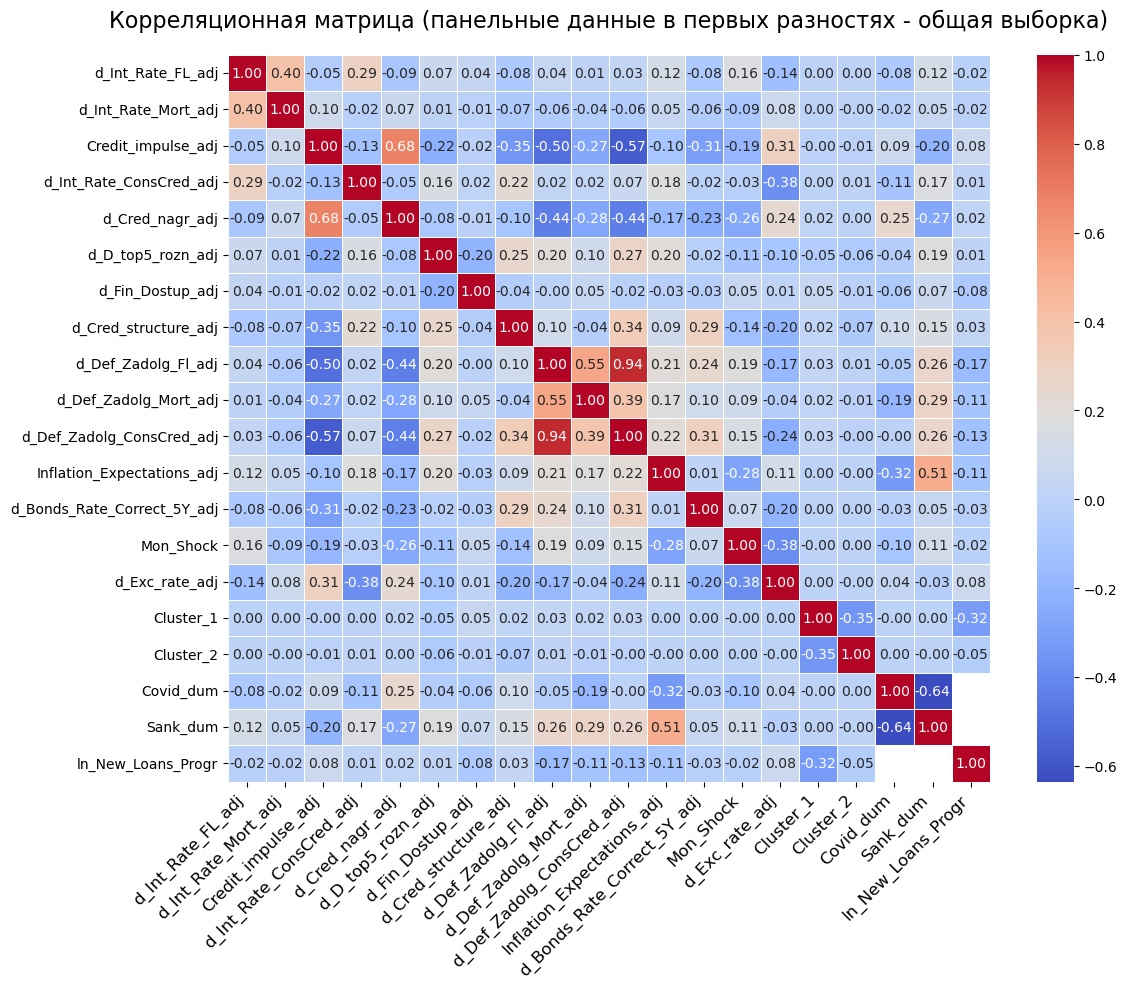

In [33]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [34]:
###############################
    #Добавление дополнительных переменных
###############################

# Кластеры * монетарный шок
df_exog['Mon_Shock_Cl1'] = df_exog['Mon_Shock'] * df_exog['Cluster_1']
df_exog['Mon_Shock_Cl2'] = df_exog['Mon_Shock'] * df_exog['Cluster_2']

# Кластеры * d_ln_ROISFIX
df_exog['d_ln_ROISFIX_Cl1'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_1']
df_exog['d_ln_ROISFIX_Cl2'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_2']

# Кластеры * d_ln_MIACR
df_exog['d_ln_MIACR_Cl1'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_1']
df_exog['d_ln_MIACR_Cl2'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_2']

# Covid * переменные интреса
df_exog['Mon_Shock_Covid']   = df_exog['Mon_Shock']   * df_exog['Covid_dum']
df_exog['d_ln_ROISFIX_Covid'] = df_exog['d_ln_ROISFIX'] * df_exog['Covid_dum']
df_exog['d_ln_MIACR_Covid']   = df_exog['d_ln_MIACR']   * df_exog['Covid_dum']

# Санкции * переменные интреса
df_exog['Mon_Shock_Sanctions']   = df_exog['Mon_Shock']   * df_exog['Sank_dum']
df_exog['d_ln_ROISFIX_Sanctions'] = df_exog['d_ln_ROISFIX'] * df_exog['Sank_dum']
df_exog['d_ln_MIACR_Sanctions']   = df_exog['d_ln_MIACR']   * df_exog['Sank_dum']


In [35]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2812 entries, 386 to 6082
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        2812 non-null   object        
 1   Date                          2812 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             2812 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        2812 non-null   float64       
 4   d_Int_Rate_Mort_adj           2812 non-null   float64       
 5   Credit_impulse_adj            2812 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      2812 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       2812 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  2812 non-null   float64       
 9   d_Cred_nagr_adj               2812 non-null   float64       
 10  d_D_top5_rozn_adj             2812 non-null   float64       
 11  d_Fin_Dostup_adj              281

In [36]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1
                   Variable      VIF
         Credit_impulse_adj 2.526819
                   Sank_dum 2.476773
            d_Cred_nagr_adj 2.175282
                  Covid_dum 1.941855
 Inflation_Expectations_adj 1.713500
                  Mon_Shock 1.632681
        d_Def_Zadolg_Fl_adj 1.585551
       d_Cred_structure_adj 1.527663
             d_Exc_rate_adj 1.353263
          d_D_top5_rozn_adj 1.263060
d_Bonds_Rate_Correct_5Y_adj 1.250116
     d_Int_Rate_FL_lag1_adj 1.106183
           d_Fin_Dostup_adj 1.067956


In [38]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2
                   Variable      VIF
         Credit_impulse_adj 2.553181
                   Sank_dum 2.493068
            d_Cred_nagr_adj 2.244235
                  Covid_dum 2.224294
                  Mon_Shock 2.023743
 Inflation_Expectations_adj 1.716431
        d_Def_Zadolg_Fl_adj 1.585575
       d_Cred_structure_adj 1.543491
            Mon_Shock_Covid 1.512586
             d_Exc_rate_adj 1.476280
          d_D_top5_rozn_adj 1.273945
d_Bonds_Rate_Correct_5Y_adj 1.252175
     d_Int_Rate_FL_lag1_adj 1.107875
           d_Fin_Dostup_adj 1.067979


In [39]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3
                   Variable      VIF
                  Mon_Shock 6.697111
              Mon_Shock_Cl1 5.910989
         Credit_impulse_adj 2.528640
                   Sank_dum 2.476808
            d_Cred_nagr_adj 2.176380
                  Covid_dum 1.941869
 Inflation_Expectations_adj 1.713641
        d_Def_Zadolg_Fl_adj 1.587352
       d_Cred_structure_adj 1.528133
             d_Exc_rate_adj 1.353291
          d_D_top5_rozn_adj 1.264694
d_Bonds_Rate_Correct_5Y_adj 1.250212
              Mon_Shock_Cl2 1.172455
     d_Int_Rate_FL_lag1_adj 1.106242
           d_Fin_Dostup_adj 1.071880


In [40]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 4 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4
                    Variable      VIF
          Credit_impulse_adj 2.555394
                    Sank_dum 2.451330
             d_Cred_nagr_adj 2.169779
                   Covid_dum 1.947492
   d_Def_Zadolg_ConsCred_adj 1.817464
  Inflation_Expectations_adj 1.739482
                   Mon_Shock 1.668912
        d_Cred_structure_adj 1.497345
              d_Exc_rate_adj 1.375209
           d_D_top5_rozn_adj 1.273880
 d_Bonds_Rate_Correct_5Y_adj 1.257353
d_Int_Rate_ConsCred_lag1_adj 1.169809
            d_Fin_Dostup_adj 1.068720


In [41]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 5 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5
                    Variable      VIF
          Credit_impulse_adj 2.585309
                    Sank_dum 2.467055
             d_Cred_nagr_adj 2.238673
                   Covid_dum 2.226879
                   Mon_Shock 2.072345
   d_Def_Zadolg_ConsCred_adj 1.818068
  Inflation_Expectations_adj 1.743320
        d_Cred_structure_adj 1.515244
             Mon_Shock_Covid 1.515080
              d_Exc_rate_adj 1.494044
           d_D_top5_rozn_adj 1.286020
 d_Bonds_Rate_Correct_5Y_adj 1.259586
d_Int_Rate_ConsCred_lag1_adj 1.173212
            d_Fin_Dostup_adj 1.068764


In [42]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 6 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6
                    Variable      VIF
                   Mon_Shock 6.736205
               Mon_Shock_Cl1 5.910618
          Credit_impulse_adj 2.557314
                    Sank_dum 2.451384
             d_Cred_nagr_adj 2.170828
                   Covid_dum 1.947502
   d_Def_Zadolg_ConsCred_adj 1.819181
  Inflation_Expectations_adj 1.739559
        d_Cred_structure_adj 1.497909
              d_Exc_rate_adj 1.375258
           d_D_top5_rozn_adj 1.275585
 d_Bonds_Rate_Correct_5Y_adj 1.257509
               Mon_Shock_Cl2 1.172891
d_Int_Rate_ConsCred_lag1_adj 1.170164
            d_Fin_Dostup_adj 1.072598


In [43]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 7 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7
                   Variable      VIF
                   Sank_dum 2.480638
         Credit_impulse_adj 2.393649
            d_Cred_nagr_adj 2.158188
                  Covid_dum 1.861550
 Inflation_Expectations_adj 1.686109
                  Mon_Shock 1.580226
       d_Cred_structure_adj 1.535897
             d_Exc_rate_adj 1.348042
          d_D_top5_rozn_adj 1.248837
d_Bonds_Rate_Correct_5Y_adj 1.231077
      d_Def_Zadolg_Mort_adj 1.202511
           d_Fin_Dostup_adj 1.069471
   d_Int_Rate_Mort_lag1_adj 1.047179


In [44]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 8 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8
                   Variable      VIF
                   Sank_dum 2.499964
         Credit_impulse_adj 2.417391
            d_Cred_nagr_adj 2.229082
                  Covid_dum 2.145999
                  Mon_Shock 1.962153
 Inflation_Expectations_adj 1.688501
       d_Cred_structure_adj 1.554444
            Mon_Shock_Covid 1.511669
             d_Exc_rate_adj 1.472651
          d_D_top5_rozn_adj 1.259574
d_Bonds_Rate_Correct_5Y_adj 1.233191
      d_Def_Zadolg_Mort_adj 1.203460
           d_Fin_Dostup_adj 1.069488
   d_Int_Rate_Mort_lag1_adj 1.047321


In [45]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 9 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9
                   Variable      VIF
                  Mon_Shock 6.652606
              Mon_Shock_Cl1 5.910442
                   Sank_dum 2.480745
         Credit_impulse_adj 2.395020
            d_Cred_nagr_adj 2.159422
                  Covid_dum 1.861587
 Inflation_Expectations_adj 1.686142
       d_Cred_structure_adj 1.536438
             d_Exc_rate_adj 1.348072
          d_D_top5_rozn_adj 1.250292
d_Bonds_Rate_Correct_5Y_adj 1.231121
      d_Def_Zadolg_Mort_adj 1.202738
              Mon_Shock_Cl2 1.171695
           d_Fin_Dostup_adj 1.073410
   d_Int_Rate_Mort_lag1_adj 1.047189


In [46]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 10 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'

]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10
                   Variable      VIF
         Credit_impulse_adj 2.767561
 Inflation_Expectations_adj 2.515301
       d_Cred_structure_adj 2.290916
d_Bonds_Rate_Correct_5Y_adj 1.984263
             d_Exc_rate_adj 1.984117
          d_D_top5_rozn_adj 1.669003
                  Mon_Shock 1.561161
            d_Cred_nagr_adj 1.405120
      d_Def_Zadolg_Mort_adj 1.232542
           d_Fin_Dostup_adj 1.168745
   d_Int_Rate_Mort_lag1_adj 1.054691
         ln_New_Loans_Progr 1.044138


In [47]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 11 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10
                   Variable      VIF
                  Mon_Shock 6.691032
              Mon_Shock_Cl1 5.979021
         Credit_impulse_adj 2.782335
 Inflation_Expectations_adj 2.515384
       d_Cred_structure_adj 2.314001
d_Bonds_Rate_Correct_5Y_adj 1.987591
             d_Exc_rate_adj 1.984548
          d_D_top5_rozn_adj 1.674985
            d_Cred_nagr_adj 1.406061
      d_Def_Zadolg_Mort_adj 1.232559
           d_Fin_Dostup_adj 1.201147
              Mon_Shock_Cl2 1.199903
   d_Int_Rate_Mort_lag1_adj 1.055770
         ln_New_Loans_Progr 1.053110


In [48]:
###############################
    #Тест на стационарность I(1) рядов для 1-го кластера
###############################

custom_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj'
]
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat  LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.038033         0.513   0.929076    0.352850 -7.489022  -8.025459        91.891892   

In [49]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1")
print("="*70)

df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_one, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.038522         0.519  -0.512061 6.086084e-01 -7.600159  -7.963224      

In [50]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2")
print("="*70)

df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_two, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue  LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.042365           NaN -0.423314 6.720660e-01 -3.016745  -3.016745        

In [51]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3")
print("="*70)

df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_three, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3
Тестирование 17 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. Inflation_Expectations_adj
  16. d_Bonds_Rate_Correct_5Y_adj
  17. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat  LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.034869         0.526   0.163769    0.869913 -7.678716  -8.720375        

In [52]:
df_exog_clus_one.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2280 entries, 386 to 6082
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        2280 non-null   object        
 1   Date                          2280 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             2280 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        2280 non-null   float64       
 4   d_Int_Rate_Mort_adj           2280 non-null   float64       
 5   Credit_impulse_adj            2280 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      2280 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       2280 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  2280 non-null   float64       
 9   d_Cred_nagr_adj               2280 non-null   float64       
 10  d_D_top5_rozn_adj             2280 non-null   float64       
 11  d_Fin_Dostup_adj              228

In [53]:
df_exog_clus_two.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76 entries, 5776 to 5851
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        76 non-null     object        
 1   Date                          76 non-null     datetime64[ns]
 2   d_Int_Rate_FL_adj             76 non-null     float64       
 3   d_Int_Rate_FL_lag1_adj        76 non-null     float64       
 4   d_Int_Rate_Mort_adj           76 non-null     float64       
 5   Credit_impulse_adj            76 non-null     float64       
 6   d_Int_Rate_Mort_lag1_adj      76 non-null     float64       
 7   d_Int_Rate_ConsCred_adj       76 non-null     float64       
 8   d_Int_Rate_ConsCred_lag1_adj  76 non-null     float64       
 9   d_Cred_nagr_adj               76 non-null     float64       
 10  d_D_top5_rozn_adj             76 non-null     float64       
 11  d_Fin_Dostup_adj              76 n

In [54]:
df_exog_clus_three.info()

<class 'pandas.core.frame.DataFrame'>
Index: 456 entries, 2234 to 6005
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        456 non-null    object        
 1   Date                          456 non-null    datetime64[ns]
 2   d_Int_Rate_FL_adj             456 non-null    float64       
 3   d_Int_Rate_FL_lag1_adj        456 non-null    float64       
 4   d_Int_Rate_Mort_adj           456 non-null    float64       
 5   Credit_impulse_adj            456 non-null    float64       
 6   d_Int_Rate_Mort_lag1_adj      456 non-null    float64       
 7   d_Int_Rate_ConsCred_adj       456 non-null    float64       
 8   d_Int_Rate_ConsCred_lag1_adj  456 non-null    float64       
 9   d_Cred_nagr_adj               456 non-null    float64       
 10  d_D_top5_rozn_adj             456 non-null    float64       
 11  d_Fin_Dostup_adj              456

In [67]:
class ModelResultsAggregator:
    '''
    Агрегирует результаты панельных регрессий (POOL, FE, RE)
    из разных спецификаций и подвыборок в единую таблицу.
    '''

    def __init__(self):
        self.results_storage = []
        self.dependent_vars = []
        self.subsamples = []

    def add_model_results(self,
                          model_results,
                          dependent_variable: str,
                          subsample_name: str,
                          model_type: str,
                          specification_name: str,
                          se_type: str | None = None):
        """
        Добавляет результаты одной модели в хранилище.

        specification_name — уникальное имя столбца
        (например 'Модель_1', 'Модель_2', ...).
        se_type — строка с типом стандартных ошибок
        (например 'robust', 'clustered (region)'...)
        """
        coefficients = model_results.params
        pvalues = model_results.pvalues

        # R^2
        try:
            r_squared = model_results.rsquared
        except Exception:
            r_squared = None

        # N
        try:
            nobs = int(model_results.nobs)
        except Exception:
            nobs = None

        # если тип SE не передан, попытаемся вытащить из атрибута модели (если есть)
        if se_type is None:
            se_type = getattr(model_results, 'cov_type', None)

        for var_name in coefficients.index:
            coef = coefficients[var_name]
            pval = pvalues[var_name]
            stars = self._get_significance_stars(pval)

            self.results_storage.append({
                'dependent_var': dependent_variable,
                'subsample': subsample_name,
                'model_type': model_type,
                'specification': specification_name,
                'variable': var_name,
                'coefficient': coef,
                'pvalue': pval,
                'stars': stars,
                'r_squared': r_squared,
                'nobs': nobs,
                'se_type': se_type
            })

        if dependent_variable not in self.dependent_vars:
            self.dependent_vars.append(dependent_variable)
        if subsample_name not in self.subsamples:
            self.subsamples.append(subsample_name)

    def _get_significance_stars(self, pvalue):
        if pd.isna(pvalue):
            return ''
        if pvalue < 0.01:
            return '***'
        elif pvalue < 0.05:
            return '**'
        elif pvalue < 0.10:
            return '*'
        else:
            return ''

    def build_table(self,
                    dependent_var_filter: str = None,
                    specification_filter: list | None = None,
                    include_pvalues: bool = True,
                    decimals: int = 3) -> pd.DataFrame:
        """
        Итоговая таблица:
        1-я строка: 'Зависимая переменная'
        2-я–...: коэффициенты и p-value по регрессорам
        строка под R^2: 'Тип стандартных ошибок'
        следующая строка: 'n-obs'
        предпоследняя строка: 'Метод оценки' (POOL/FE/RE)
        последняя строка: 'Выборка'.
        """
        df = pd.DataFrame(self.results_storage)

        # фильтры
        if dependent_var_filter:
            df = df[df['dependent_var'] == dependent_var_filter]
        if specification_filter is not None:
            df = df[df['specification'].isin(specification_filter)]

        # порядок столбцов по спецификациям
        col_order = list(dict.fromkeys(df['specification']))

        # тело таблицы
        body_dict = {}
        for spec in col_order:
            subset = df[df['specification'] == spec]
            col_data = {}
            for _, row in subset.iterrows():
                var = row['variable']
                coef = row['coefficient']
                stars = row['stars']
                pval = row['pvalue']

                if include_pvalues and pd.notna(pval):
                    cell = f"{coef:.{decimals}f}{stars} ({pval:.{decimals}f})"
                else:
                    cell = f"{coef:.{decimals}f}{stars}"

                col_data[var] = cell
            body_dict[spec] = col_data

        body_df = pd.DataFrame(body_dict).reindex(columns=col_order).fillna('')

        # Зависимая переменная (верхняя строка)
        dep_names = (df.groupby('specification')['dependent_var']
                       .first()
                       .reindex(col_order))
        dep_row = pd.DataFrame([dep_names], index=['Зависимая переменная'])

        # R^2
        r2_vals = (df.groupby('specification')['r_squared']
                     .max()
                     .round(decimals)
                     .reindex(col_order))
        r2_row = pd.DataFrame([r2_vals], index=['R^2'])

        # Тип стандартных ошибок (под R^2)
        se_vals = (df.groupby('specification')['se_type']
                     .first()
                     .reindex(col_order))
        se_row = pd.DataFrame([se_vals], index=['Тип стандартных ошибок'])

        # n-obs (число наблюдений)
        nobs_vals = (df.groupby('specification')['nobs']
                       .max()
                       .reindex(col_order))
        nobs_row = pd.DataFrame([nobs_vals], index=['n-obs'])

        # Метод оценки (предпоследняя строка)
        model_names = (df.groupby('specification')['model_type']
                         .first()
                         .reindex(col_order))
        model_row = pd.DataFrame([model_names], index=['Метод оценки'])

        # Выборка (последняя строка)
        subsample_vals = (df.groupby('specification')['subsample']
                            .first()
                            .reindex(col_order))
        subsample_row = pd.DataFrame([subsample_vals], index=['Выборка'])

        # Итог: Зависимая переменная -> тело -> R^2 -> Тип SE -> n-obs -> Метод -> Выборка
        output_df = pd.concat(
            [dep_row, body_df, r2_row, se_row, nobs_row, model_row, subsample_row],
            axis=0
        )
        return output_df

    def build_summary_table(self,
                            dependent_var_filter: str = None,
                            decimals: int = 3) -> pd.DataFrame:
        """
        Сводная таблица по спецификациям (как дополнение к основной).
        Внизу остаётся строка с N (как раньше).
        """
        df = pd.DataFrame(self.results_storage)

        if dependent_var_filter:
            df = df[df['dependent_var'] == dependent_var_filter]

        df['col_name'] = df['specification']

        df['formatted_coef'] = (df['coefficient'].round(decimals).astype(str) +
                                df['stars'])
        df['formatted_pval'] = '(' + df['pvalue'].round(decimals).astype(str) + ')'

        result = df.groupby(['variable', 'col_name']).apply(
            lambda x: ' '.join([x.iloc[0]['formatted_coef'],
                                x.iloc[0]['formatted_pval']])
        ).unstack(fill_value='')

        # строка с N внизу (можно оставить как N, чтобы не ломать старый код)
        nobs_table = (df.groupby('col_name')['nobs']
                        .max()
                        .rename('N')
                        .to_frame()
                        .T)
        nobs_table = nobs_table.astype('Int64').astype(str)

        result = pd.concat([result, nobs_table])
        return result


In [68]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.0839
Estimator:                  PooledOLS   R-squared (Between):              0.7898
No. Observations:                2812   R-squared (Within):               0.0789
Date:                 Ср, дек 24 2025   R-squared (Overall):              0.0839
Time:                        17:50:06   Log-likelihood                   -3976.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.383
Entities:                          37   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(12,2800)
Min Obs:                       76.000                                       

In [69]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -455.5809
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1420.0830
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -46.1334
p-значение: 1.000000
df: (36, 2763)

Вывод: p >= 0.05 - Pooled адекватна


In [70]:
# Добавляем результаты в сводную таблицу
aggregator_Int_FL = ModelResultsAggregator()

aggregator_Int_FL.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_1',
    se_type = 'Clustered'
)


In [71]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.0902
Estimator:                  PooledOLS   R-squared (Between):              0.7926
No. Observations:                2812   R-squared (Within):               0.0852
Date:                 Ср, дек 24 2025   R-squared (Overall):              0.0902
Time:                        17:50:06   Log-likelihood                   -3966.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.351
Entities:                          37   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(13,2799)
Min Obs:                       76.000                                       

In [72]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -343.4245
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1420.1131
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -46.8270
p-значение: 1.000000
df: (36, 2762)

Вывод: p >= 0.05 - Pooled адекватна


In [73]:
# Добавляем результаты в сводную таблицу

aggregator_Int_FL.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_2',
    se_type = 'Clustered'
)


In [74]:
###############################
# Построение линейных моделей на панельных данных - общая выборка
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.0840
Estimator:                  PooledOLS   R-squared (Between):              0.7882
No. Observations:                2812   R-squared (Within):               0.0790
Date:                 Ср, дек 24 2025   R-squared (Overall):              0.0840
Time:                        17:50:07   Log-likelihood                   -3976.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.333
Entities:                          37   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(14,2798)
Min Obs:                       76.000                                       

In [75]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -470.6733
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1420.0486
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -46.1269
p-значение: 1.000000
df: (36, 2761)

Вывод: p >= 0.05 - Pooled адекватна


In [76]:
# Добавляем результаты в сводную таблицу
aggregator_Int_FL.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_3',
    se_type = 'Clustered'
)

In [77]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2682
Estimator:                       PooledOLS   R-squared (Between):              0.9201
No. Observations:                     2812   R-squared (Within):               0.2515
Date:                      Ср, дек 24 2025   R-squared (Overall):              0.2682
Time:                             17:50:07   Log-likelihood                   -4099.7
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      78.896
Entities:                               37   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                 F(13,2799)
Min Obs:            

In [78]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -173.5823
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1417.0083
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -45.7666
p-значение: 1.000000
df: (36, 2762)

Вывод: p >= 0.05 - Pooled адекватна


In [79]:
# Добавляем результаты в сводную таблицу
aggregator_Int_ConsCred = ModelResultsAggregator()

aggregator_Int_ConsCred.add_model_results(
    fe_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_4',
    se_type = 'Clustered'
)

In [80]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2765
Estimator:                       PooledOLS   R-squared (Between):              0.9239
No. Observations:                     2812   R-squared (Within):               0.2599
Date:                      Ср, дек 24 2025   R-squared (Overall):              0.2765
Time:                             17:50:08   Log-likelihood                   -4083.6
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      76.374
Entities:                               37   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                 F(14,2798)
Min Obs:            

In [81]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -71.5630
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1417.2930
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -45.3246
p-значение: 1.000000
df: (36, 2761)

Вывод: p >= 0.05 - Pooled адекватна


In [82]:
# Добавляем результаты в сводную таблицу
aggregator_Int_ConsCred.add_model_results(
    fe_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_5',
    se_type = 'Clustered'
)

In [83]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2682
Estimator:                       PooledOLS   R-squared (Between):              0.9205
No. Observations:                     2812   R-squared (Within):               0.2515
Date:                      Ср, дек 24 2025   R-squared (Overall):              0.2682
Time:                             17:50:37   Log-likelihood                   -4099.6
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      68.340
Entities:                               37   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                 F(15,2797)
Min Obs:            

In [84]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -180.4751
p-значение: 1.000000
df: 15

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1417.0487
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -45.7420
p-значение: 1.000000
df: (36, 2760)

Вывод: p >= 0.05 - Pooled адекватна


In [85]:
# Добавляем результаты в сводную таблицу
aggregator_Int_ConsCred.add_model_results(
    fe_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_6',
    se_type = 'Clustered'
)

In [86]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1001
Estimator:                   PooledOLS   R-squared (Between):              0.3930
No. Observations:                 2812   R-squared (Within):               0.0991
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.1001
Time:                         17:50:38   Log-likelihood                   -2658.3
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      23.944
Entities:                           37   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(13,2799)
Min Obs:                        76.000                          

In [87]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -146.5750
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1418.1350
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.4528
p-значение: 1.000000
df: (36, 2762)

Вывод: p >= 0.05 - Pooled адекватна


In [88]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort = ModelResultsAggregator()

aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_7',
    se_type = 'Clustered'
)

In [89]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1006
Estimator:                   PooledOLS   R-squared (Between):              0.4003
No. Observations:                 2812   R-squared (Within):               0.0995
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.1006
Time:                         17:51:23   Log-likelihood                   -2657.5
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      22.346
Entities:                           37   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(14,2798)
Min Obs:                        76.000                          

In [90]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -184.1317
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1418.2112
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.5891
p-значение: 1.000000
df: (36, 2761)

Вывод: p >= 0.05 - Pooled адекватна


In [91]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_8',
    se_type = 'Clustered'
)

In [92]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1001
Estimator:                   PooledOLS   R-squared (Between):              0.3968
No. Observations:                 2812   R-squared (Within):               0.0991
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.1001
Time:                         17:51:44   Log-likelihood                   -2658.2
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      20.751
Entities:                           37   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(15,2797)
Min Obs:                        76.000                          

In [93]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -197.8351
p-значение: 1.000000
df: 15

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1418.1758
p-значение: 0.000000
N (регионов): 37, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.4382
p-значение: 1.000000
df: (36, 2760)

Вывод: p >= 0.05 - Pooled адекватна


In [94]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_9',
    se_type = 'Clustered'
)

In [95]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.2141
Estimator:                   PooledOLS   R-squared (Between):             -1.6611
No. Observations:                  703   R-squared (Within):               0.2192
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.2141
Time:                         17:51:51   Log-likelihood                   -922.84
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      15.689
Entities:                           37   P-value                           0.0000
Avg Obs:                        19.000   Distribution:                  F(12,691)
Min Obs:                        19.000                          

In [96]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -8.1335
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 364.2657
p-значение: 0.000000
N (регионов): 37, T (периодов): 19

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2497
p-значение: 1.000000
df: (36, 654)

Вывод: p >= 0.05 - Pooled адекватна


In [97]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_10',
    se_type = 'Clustered'
)

In [98]:
###############################
# Построение линейных моделей на панельных данных (общая выборка)
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.2151
Estimator:                   PooledOLS   R-squared (Between):             -1.5905
No. Observations:                  703   R-squared (Within):               0.2200
Date:                  Ср, дек 24 2025   R-squared (Overall):              0.2151
Time:                         17:51:51   Log-likelihood                   -922.40
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      13.487
Entities:                           37   P-value                           0.0000
Avg Obs:                        19.000   Distribution:                  F(14,689)
Min Obs:                        19.000                          

In [99]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -8.3484
p-значение: 1.000000
df: 14

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 364.4362
p-значение: 0.000000
N (регионов): 37, T (периодов): 19

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2222
p-значение: 1.000000
df: (36, 652)

Вывод: p >= 0.05 - Pooled адекватна


In [102]:
# Добавляем результаты в сводную таблицу
aggregator_Int_Mort.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_11',
    se_type = 'Clustered'
)

In [113]:
full_table_Int_FL = aggregator_Int_FL.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_FL)

                                       Модель_1            Модель_2  \
Зависимая переменная          d_Int_Rate_FL_adj   d_Int_Rate_FL_adj   
d_Int_Rate_FL_lag1_adj         -0.149** (0.018)    -0.153** (0.015)   
d_Cred_nagr_adj                  -4.079 (0.276)      -2.260 (0.593)   
d_D_top5_rozn_adj              30.196** (0.016)   32.197*** (0.010)   
d_Fin_Dostup_adj                 0.142* (0.097)      0.143* (0.098)   
Credit_impulse_adj               -0.004 (0.456)      -0.005 (0.353)   
d_Cred_structure_adj         -29.265*** (0.001)  -27.880*** (0.001)   
d_Def_Zadolg_Fl_adj              -0.402 (0.140)      -0.402 (0.141)   
Mon_Shock                      2.989*** (0.000)    3.600*** (0.000)   
d_Bonds_Rate_Correct_5Y_adj   -0.419*** (0.010)    -0.414** (0.011)   
Inflation_Expectations_adj      0.006** (0.029)     0.007** (0.014)   
Covid_dum                        -0.024 (0.469)   -0.118*** (0.005)   
Sank_dum                       0.168*** (0.000)    0.157*** (0.000)   
Mon_Sh

In [114]:
full_table_Int_ConsCred = aggregator_Int_ConsCred.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_ConsCred)

                                             Модель_4  \
Зависимая переменная          d_Int_Rate_ConsCred_adj   
d_Int_Rate_ConsCred_lag1_adj         -0.131** (0.047)   
d_Cred_nagr_adj                         6.367 (0.576)   
d_D_top5_rozn_adj                      18.188 (0.120)   
d_Fin_Dostup_adj                     0.180*** (0.004)   
Credit_impulse_adj                     -0.010 (0.416)   
d_Cred_structure_adj                57.253*** (0.000)   
d_Def_Zadolg_ConsCred_adj           -0.701*** (0.000)   
Mon_Shock                           -1.511*** (0.001)   
d_Bonds_Rate_Correct_5Y_adj         -0.758*** (0.000)   
d_Exc_rate_adj                      -0.110*** (0.000)   
Inflation_Expectations_adj           0.121*** (0.000)   
Covid_dum                            -0.123** (0.012)   
Sank_dum                             0.157*** (0.000)   
Mon_Shock_Covid                                         
Mon_Shock_Cl1                                           
Mon_Shock_Cl2                  

In [115]:
full_table_Int_Mort = aggregator_Int_Mort.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table_Int_Mort)

                                        Модель_7             Модель_8  \
Зависимая переменная         d_Int_Rate_Mort_adj  d_Int_Rate_Mort_adj   
d_Int_Rate_Mort_lag1_adj       -0.272*** (0.000)    -0.272*** (0.000)   
d_Cred_nagr_adj                    0.944 (0.471)        1.275 (0.351)   
d_D_top5_rozn_adj                  2.736 (0.709)        3.264 (0.656)   
d_Fin_Dostup_adj                  -0.003 (0.945)       -0.003 (0.949)   
Credit_impulse_adj                0.005* (0.078)        0.005 (0.102)   
d_Cred_structure_adj           -13.676** (0.024)    -13.078** (0.034)   
d_Def_Zadolg_Mort_adj            -0.729* (0.077)      -0.719* (0.081)   
Mon_Shock                      -0.861*** (0.002)     -0.718** (0.041)   
d_Bonds_Rate_Correct_5Y_adj     -0.127** (0.040)     -0.124** (0.045)   
d_Exc_rate_adj                     0.003 (0.313)        0.004 (0.208)   
Inflation_Expectations_adj     -0.010*** (0.000)    -0.010*** (0.000)   
Covid_dum                         -0.003 (0.898)   

In [96]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
###############################
descriptive_df = df_exog_clus_one[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Covid_dum',
    'Sank_dum'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.079   -0.038      1.069 -13.724  13.319
d_Int_Rate_Mort_adj           -0.034   -0.042      0.677  -4.479   5.582
Credit_impulse_adj            -0.630   -0.032      7.268 -55.926  56.097
d_Int_Rate_ConsCred_adj        0.182    0.032      1.298 -16.410  21.073
d_Cred_nagr_adj               -0.001    0.000      0.010  -0.059   0.037
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.036
d_Fin_Dostup_adj              -0.042   -0.023      0.260  -5.750   3.483
d_Cred_structure_adj           0.001    0.001      0.003  -0.022   0.021
d_Def_Zadolg_Fl_adj            0.006   -0.009      0.098  -0.834   1.286
d_Def_Zadolg_Mort_adj          0.000   -0.004      0.045  -0.584   0.544
d_Def_Zadolg_ConsCred_adj      0.030    0.002      0.175  -1.049   2.716
d_ln_New_Loans_Fl_adj          0.007    0.021    

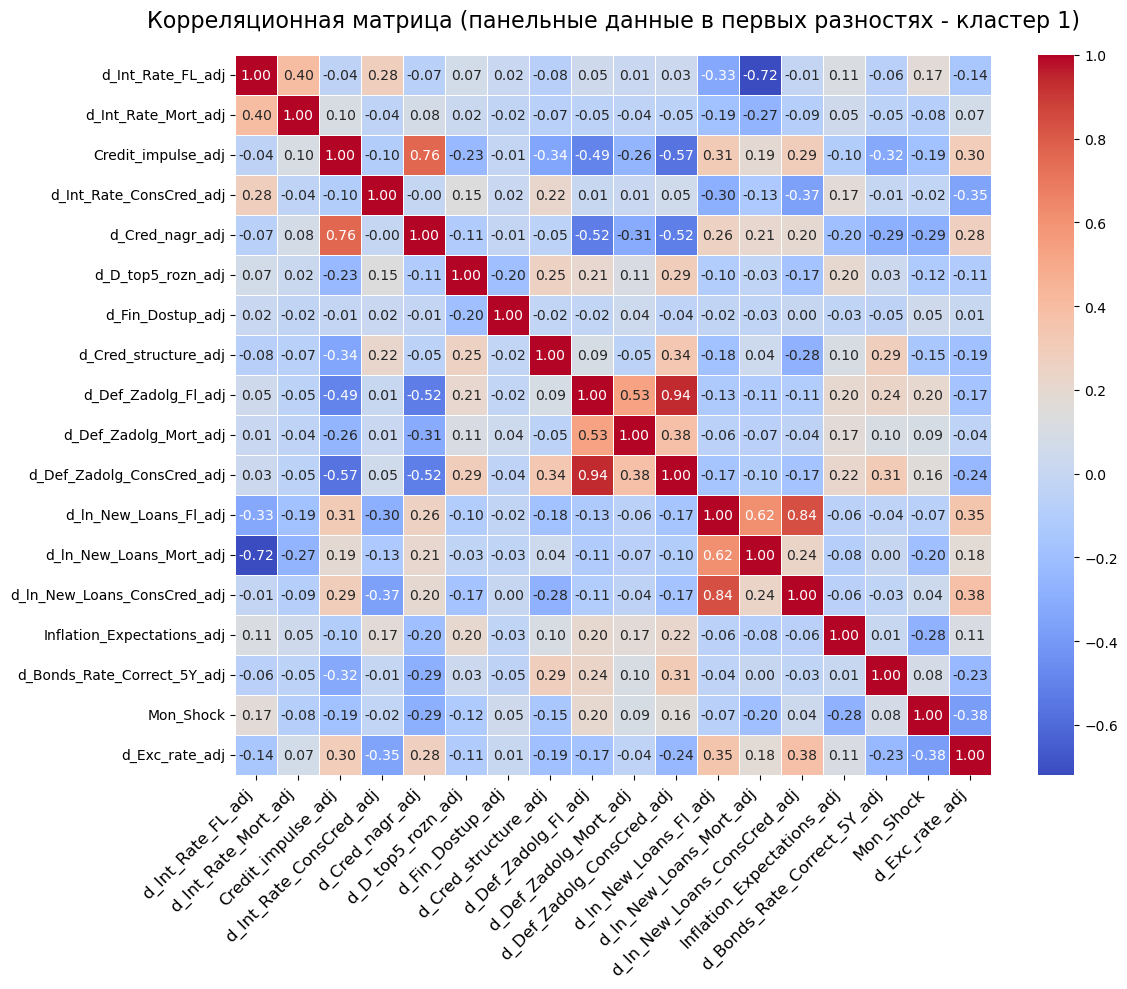

In [97]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 1
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 1)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [98]:
###############################
# Построение линейных моделей на панельных данных - кластер 1
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1770
Estimator:                  PooledOLS   R-squared (Between):              0.6385
No. Observations:                2280   R-squared (Within):               0.1744
Date:                 Пн, дек 22 2025   R-squared (Overall):              0.1770
Time:                        17:53:02   Log-likelihood                   -3171.4
Cov. Estimator:                Robust                                           
                                        F-statistic:                      44.370
Entities:                          30   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(11,2269)
Min Obs:                       76.000                                           

In [99]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -2.3367
p-значение: 1.000000
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.4296
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -44.6675
p-значение: 1.000000
df: (29, 2239)

Вывод: p >= 0.05 - Pooled адекватна


In [100]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_4'
)

In [101]:
###############################
# Построение линейных моделей на панельных данных (кластер 1)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2677
Estimator:                       PooledOLS   R-squared (Between):              0.8930
No. Observations:                     2280   R-squared (Within):               0.2545
Date:                      Пн, дек 22 2025   R-squared (Overall):              0.2677
Time:                             17:53:02   Log-likelihood                   -3496.6
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      69.091
Entities:                               30   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                 F(12,2268)
Min Obs:                

In [102]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 31.1689
p-значение: 0.001856
df: 12

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1148.2277
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -56.0717
p-значение: 1.000000
df: (29, 2238)

Вывод: p >= 0.05 - Pooled адекватна


In [103]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_1',
    model_type='FE',
    specification_name='Модель_5'
)

In [104]:
###############################
# Построение линейных моделей на панельных данных (кластер 1)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1980
Estimator:                   PooledOLS   R-squared (Between):              0.4039
No. Observations:                 2280   R-squared (Within):               0.1973
Date:                  Пн, дек 22 2025   R-squared (Overall):              0.1980
Time:                         17:53:03   Log-likelihood                   -2098.2
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      46.658
Entities:                           30   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,2268)
Min Obs:                        76.000                              

In [105]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.2029
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.0890
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -9.7013
p-значение: 1.000000
df: (29, 2238)

Вывод: p >= 0.05 - Pooled адекватна


In [106]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_6'
)

In [107]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
###############################
descriptive_df = df_exog_clus_two[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.069   -0.032      1.056  -2.825   5.474
d_Int_Rate_Mort_adj           -0.055   -0.076      0.637  -3.539   2.901
Credit_impulse_adj            -1.041   -0.242      7.272 -38.748  28.841
d_Int_Rate_ConsCred_adj        0.221    0.039      2.142 -12.313  20.565
d_Cred_nagr_adj               -0.001   -0.001      0.007  -0.019   0.018
d_D_top5_rozn_adj              0.000   -0.000      0.002  -0.004   0.008
d_Fin_Dostup_adj              -0.067   -0.034      0.483  -3.693   3.597
d_Cred_structure_adj           0.001    0.002      0.004  -0.013   0.019
d_Def_Zadolg_Fl_adj            0.002   -0.004      0.070  -0.212   0.244
d_Def_Zadolg_Mort_adj         -0.003   -0.004      0.022  -0.058   0.095
d_Def_Zadolg_ConsCred_adj      0.032    0.013      0.149  -0.329   0.747
d_ln_New_Loans_Fl_adj          0.004    0.016    

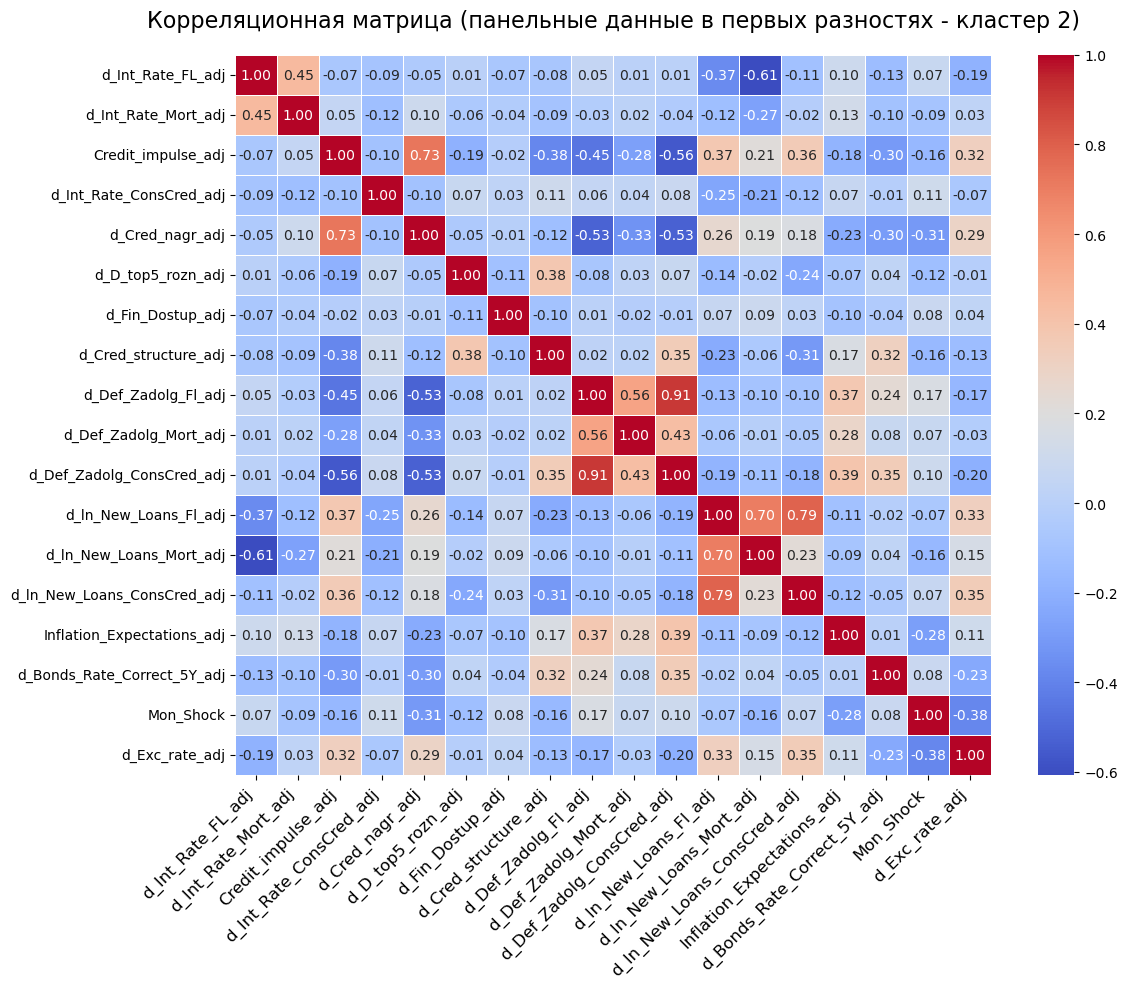

In [108]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 2)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [109]:
###############################
# Построение линейных моделей на панельных данных - кластер 2
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1883
Estimator:                  PooledOLS   R-squared (Between):              0.8843
No. Observations:                 228   R-squared (Within):               0.1846
Date:                 Пн, дек 22 2025   R-squared (Overall):              0.1883
Time:                        17:53:05   Log-likelihood                   -312.20
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4.5775
Entities:                           3   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                  F(11,217)
Min Obs:                       76.000                                           

In [110]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.5269
p-значение: 0.999998
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.3463
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -43.5550
p-значение: 1.000000
df: (2, 214)

Вывод: p >= 0.05 - Pooled адекватна


In [111]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_7'
)

In [112]:
###############################
# Построение линейных моделей на панельных данных (кластер 2)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.1931
Estimator:                       PooledOLS   R-squared (Between):              0.8361
No. Observations:                      228   R-squared (Within):               0.1862
Date:                      Пн, дек 22 2025   R-squared (Overall):              0.1931
Time:                             17:53:05   Log-likelihood                   -473.42
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      4.3079
Entities:                                3   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                  F(12,216)
Min Obs:                

In [113]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0873
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.0248
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -33.4263
p-значение: 1.000000
df: (2, 213)

Вывод: p >= 0.05 - Pooled адекватна


In [114]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_8'
)

In [115]:
###############################
# Построение линейных моделей на панельных данных (кластер 2)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1673
Estimator:                   PooledOLS   R-squared (Between):              0.9300
No. Observations:                  228   R-squared (Within):               0.1609
Date:                  Пн, дек 22 2025   R-squared (Overall):              0.1673
Time:                         17:53:06   Log-likelihood                   -200.28
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      3.6158
Entities:                            3   P-value                           0.0001
Avg Obs:                        76.000   Distribution:                  F(12,216)
Min Obs:                        76.000                              

In [116]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 3.5290
p-значение: 0.990518
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.3599
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -54.5631
p-значение: 1.000000
df: (2, 213)

Вывод: p >= 0.05 - Pooled адекватна


In [117]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_9'
)

In [118]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 3
###############################
descriptive_df = df_exog_clus_three[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 2
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.077   -0.025      0.886  -2.040   5.028
d_Int_Rate_Mort_adj           -0.038   -0.073      0.502  -2.957   3.138
Credit_impulse_adj            -0.500   -0.114      5.279 -19.754  19.222
d_Int_Rate_ConsCred_adj        0.174    0.038      1.041  -3.936   7.515
d_Cred_nagr_adj               -0.001   -0.000      0.010  -0.034   0.027
d_D_top5_rozn_adj              0.002    0.001      0.003  -0.005   0.037
d_Fin_Dostup_adj              -0.073   -0.064      0.185  -1.337   0.871
d_Cred_structure_adj           0.002    0.002      0.003  -0.008   0.020
d_Def_Zadolg_Fl_adj           -0.005   -0.016      0.073  -0.297   0.461
d_Def_Zadolg_Mort_adj         -0.002   -0.004      0.027  -0.210   0.179
d_Def_Zadolg_ConsCred_adj      0.018   -0.020      0.144  -0.517   0.951
d_ln_New_Loans_Fl_adj          0.007    0.019    

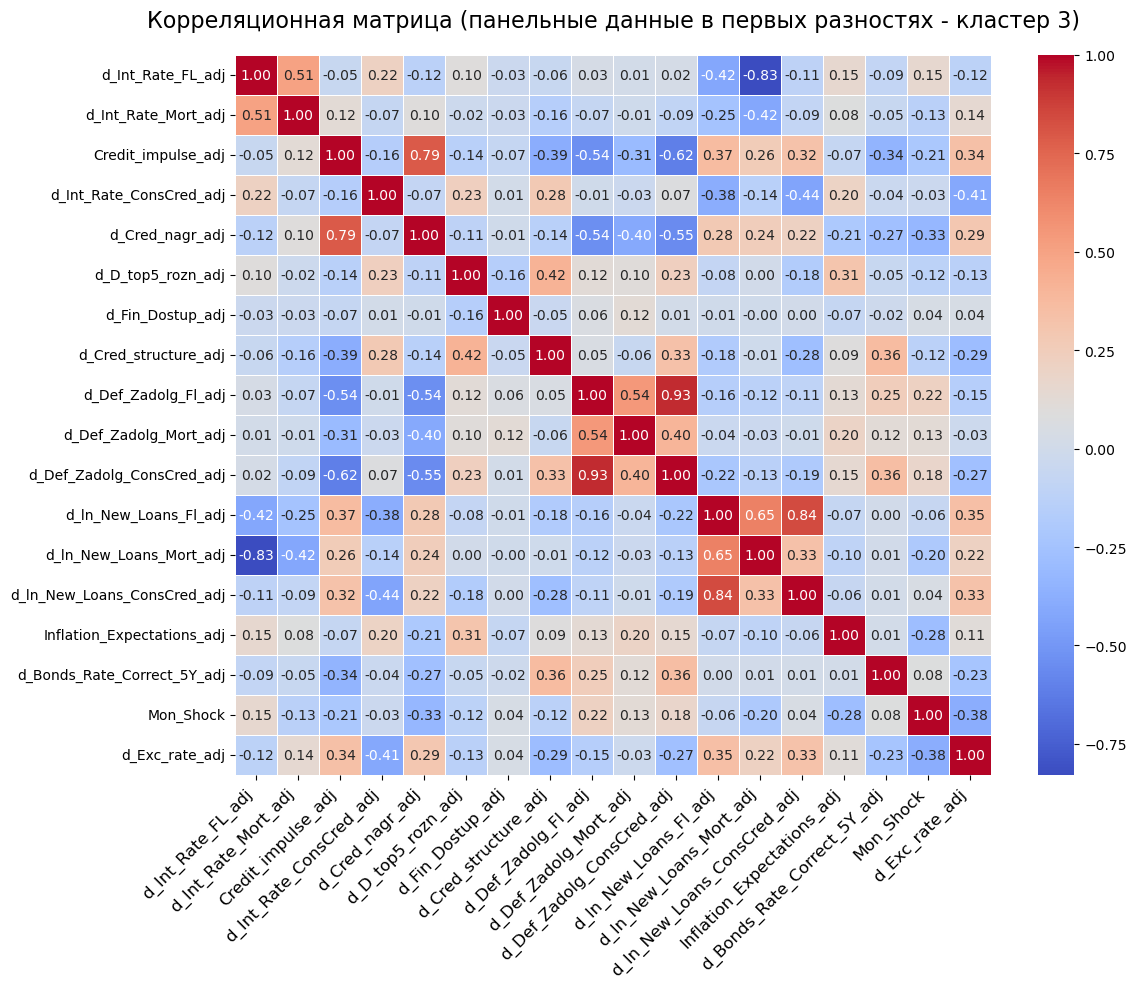

In [119]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - КЛАСТЕР 3
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - кластер 3)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [120]:
###############################
# Построение линейных моделей на панельных данных - кластер 3
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                               
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)
Зависимая переменная: d_Int_Rate_FL_adj

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.2569
Estimator:                  PooledOLS   R-squared (Between):              0.9367
No. Observations:                 532   R-squared (Within):               0.2517
Date:                 Пн, дек 22 2025   R-squared (Overall):              0.2569
Time:                        17:55:18   Log-likelihood                   -613.05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      16.376
Entities:                           7   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                  F(11,521)
Min Obs:                       76.000                                           

In [121]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 8.7405
p-значение: 0.645829
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.1966
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -44.7128
p-значение: 1.000000
df: (6, 514)

Вывод: p >= 0.05 - Pooled адекватна


In [122]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_10'
)

In [123]:
###############################
# Построение линейных моделей на панельных данных (кластер 3)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                             
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)
Зависимая переменная: d_Int_Rate_ConsCred_adj

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.3583
Estimator:                       PooledOLS   R-squared (Between):              0.9583
No. Observations:                      532   R-squared (Within):               0.3415
Date:                      Пн, дек 22 2025   R-squared (Overall):              0.3583
Time:                             17:55:18   Log-likelihood                   -665.17
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      24.201
Entities:                                7   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                  F(12,520)
Min Obs:                

In [124]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -2.3287
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 268.5889
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -63.5228
p-значение: 1.000000
df: (6, 513)

Вывод: p >= 0.05 - Pooled адекватна


In [125]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_11'
)

In [126]:
###############################
# Построение линейных моделей на панельных данных (кластер 3)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3)
Зависимая переменная: d_Int_Rate_Mort_adj

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.3252
Estimator:                   PooledOLS   R-squared (Between):              0.9899
No. Observations:                  532   R-squared (Within):               0.3215
Date:                  Пн, дек 22 2025   R-squared (Overall):              0.3252
Time:                         17:56:05   Log-likelihood                   -285.04
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      20.886
Entities:                            7   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                  F(12,520)
Min Obs:                        76.000                              

In [127]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0078
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.5011
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2847
p-значение: 1.000000
df: (6, 513)

Вывод: p >= 0.05 - Pooled адекватна


In [128]:
# Добавляем результаты в сводную таблицу
aggregator.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_12'
)

In [129]:
full_table = aggregator.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table)

                                        Модель_1                 Модель_2  \
Зависимая переменная           d_Int_Rate_FL_adj  d_Int_Rate_ConsCred_adj   
d_Int_Rate_FL_lag1_adj            -0.107 (0.104)                            
d_Cred_nagr_adj                    1.932 (0.641)         10.583** (0.041)   
d_D_top5_rozn_adj              31.608*** (0.007)        28.149*** (0.005)   
d_Fin_Dostup_adj                   0.019 (0.767)         0.224*** (0.001)   
Credit_impulse_adj                 0.007 (0.215)           -0.006 (0.490)   
d_Cred_structure_adj          -42.140*** (0.000)        37.559*** (0.000)   
d_Def_Zadolg_Fl_adj               -0.084 (0.763)                            
Mon_Shock                       2.938*** (0.000)           -0.297 (0.670)   
d_ln_New_Loans_Fl_adj          -2.948*** (0.000)                            
d_Bonds_Rate_Correct_5Y_adj       -0.223 (0.172)        -0.561*** (0.001)   
Inflation_Expectations_adj      0.017*** (0.000)         0.019*** (0.000)   

In [130]:
#full_table.to_excel('results_panel.xlsx')

In [55]:
###########################################
 #ПОСТРОЕНИЕ МОДЕЛЕЙ С ROISFIX
###########################################
df_exog = pd.read_excel('exog.xlsx')

In [56]:
df_roisfix.head()

,Date,d_ln_ROISFIX
0,2019-03-01,-0.005307
1,2019-04-01,0.002428
2,2019-05-01,0.000728
3,2019-06-01,-0.014620
4,2019-07-01,-0.024679


In [57]:
df_exog.head()

,Region,Date,d_Int_Rate_FL_adj,d_Int_Rate_FL_lag1_adj,d_Int_Rate_Mort_adj,Credit_impulse_adj,d_Int_Rate_Mort_lag1_adj,d_Int_Rate_ConsCred_adj,d_Int_Rate_ConsCred_lag1_adj,d_Cred_nagr_adj,...,d_Def_Zadolg_ConsCred_adj,d_ln_New_Loans_Fl_adj,d_ln_New_Loans_Mort_adj,d_ln_New_Loans_ConsCred_adj,Inflation_Expectations_adj,d_Bonds_Rate_Correct_5Y_adj,Mon_Shock,d_Exc_rate_adj,Cluster_1,Cluster_2
0,Алтайский край,2019-05-01,0.002751,0.332021,0.222952,2.896283,0.534088,-0.009904,0.094145,0.001391,...,-0.188653,0.076853,0.087517,0.035261,9.556202,-0.118900,-0.003213,2.202704,1,0
1,Алтайский край,2019-06-01,-0.135162,0.028915,-0.013543,3.008792,0.175740,-0.029205,0.005160,0.000063,...,-0.163713,0.037104,0.018172,-0.052758,9.236921,-0.018078,-0.015468,1.590251,1,0
2,Алтайский край,2019-07-01,-0.011789,-0.142436,0.120897,2.623327,-0.231480,-0.062038,-0.020563,0.001691,...,-0.188312,-0.101967,-0.014579,-0.078541,9.331369,-0.023652,-0.000333,-1.536596,1,0
3,Алтайский край,2019-08-01,0.303013,-0.030554,-0.241133,3.494039,-0.121719,0.220345,-0.071617,0.001204,...,-0.071152,0.027416,-0.053992,0.056817,9.330758,0.002706,0.005457,0.875305,1,0
4,Алтайский край,2019-09-01,-0.173113,0.204788,-0.288290,3.024105,-0.058210,-0.052563,0.227203,0.001501,...,-0.214003,-0.016606,0.047768,-0.009646,9.170678,0.049196,0.013868,-0.651120,1,0


In [58]:
df_exog = df_exog.merge(
    df_roisfix,
    on='Date',         
    how='left'         
)


In [59]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        3040 non-null   object        
 1   Date                          3040 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             3040 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        3040 non-null   float64       
 4   d_Int_Rate_Mort_adj           3040 non-null   float64       
 5   Credit_impulse_adj            3040 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      3040 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       3040 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  3040 non-null   float64       
 9   d_Cred_nagr_adj               3040 non-null   float64       
 10  d_D_top5_rozn_adj             3040 non-null   float64       
 11  d_Fin_Dostup_adj              

In [60]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1 (ROISFIX)")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1 (ROISFIX)
                   Variable      VIF
               d_ln_ROISFIX 3.671867
            d_Cred_nagr_adj 3.368960
         Credit_impulse_adj 3.201396
             d_Exc_rate_adj 2.385301
 Inflation_Expectations_adj 2.026036
        d_Def_Zadolg_Fl_adj 1.537617
       d_Cred_structure_adj 1.501195
d_Bonds_Rate_Correct_5Y_adj 1.353111
      d_ln_New_Loans_Fl_adj 1.301104
          d_D_top5_rozn_adj 1.225218
     d_Int_Rate_FL_lag1_adj 1.114957
           d_Fin_Dostup_adj 1.039579


In [61]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2 (ROISFIX)")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2 (ROISFIX)
                    Variable      VIF
                d_ln_ROISFIX 3.647655
             d_Cred_nagr_adj 3.348261
          Credit_impulse_adj 3.215639
              d_Exc_rate_adj 2.507511
  Inflation_Expectations_adj 1.985637
   d_Def_Zadolg_ConsCred_adj 1.758628
        d_Cred_structure_adj 1.549090
 d_ln_New_Loans_ConsCred_adj 1.372839
 d_Bonds_Rate_Correct_5Y_adj 1.330099
           d_D_top5_rozn_adj 1.230726
d_Int_Rate_ConsCred_lag1_adj 1.078630
            d_Fin_Dostup_adj 1.039755


In [62]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация (ROISFIX)
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                     
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3 (ROISFIX)")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3 (ROISFIX)
                   Variable      VIF
               d_ln_ROISFIX 3.387480
            d_Cred_nagr_adj 3.318107
         Credit_impulse_adj 3.096494
             d_Exc_rate_adj 2.131450
 Inflation_Expectations_adj 1.938486
       d_Cred_structure_adj 1.510130
d_Bonds_Rate_Correct_5Y_adj 1.319531
          d_D_top5_rozn_adj 1.218535
      d_Def_Zadolg_Mort_adj 1.162935
    d_ln_New_Loans_Mort_adj 1.097798
           d_Fin_Dostup_adj 1.042224
   d_Int_Rate_Mort_lag1_adj 1.041451


In [63]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_ln_ROISFIX',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.078   -0.035      1.038 -13.724  13.319
d_Int_Rate_Mort_adj           -0.036   -0.053      0.647  -4.479   5.582
Credit_impulse_adj            -0.638   -0.061      6.961 -55.926  56.097
d_Int_Rate_ConsCred_adj        0.184    0.035      1.340 -16.410  21.073
d_Cred_nagr_adj               -0.001    0.000      0.010  -0.059   0.037
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.037
d_Fin_Dostup_adj              -0.049   -0.030      0.273  -5.750   3.597
d_Cred_structure_adj           0.001    0.001      0.003  -0.022   0.021
d_Def_Zadolg_Fl_adj            0.003   -0.010      0.093  -0.834   1.286
d_Def_Zadolg_Mort_adj         -0.000   -0.004      0.041  -0.584   0.544
d_Def_Zadolg_ConsCred_adj      0.028    0.001      0.168  -1.049   2.716
d_ln_New_Loans_Fl_adj          0.00

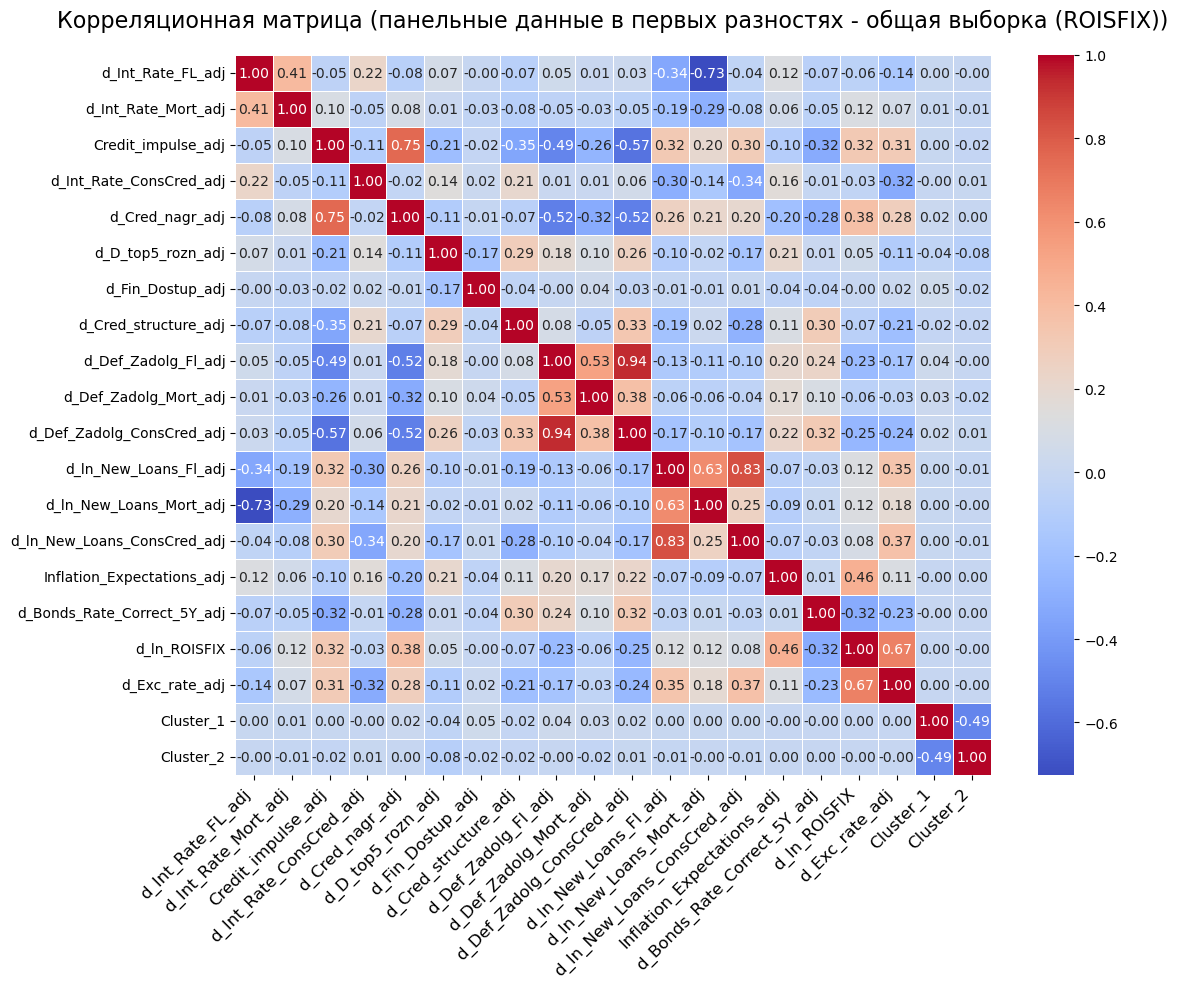

In [64]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА (ROISFIX)
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка (ROISFIX))",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [65]:
###############################
# Построение линейных моделей на панельных данных - общая выборка ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА) - ROISFIX
Зависимая переменная: d_Int_Rate_FL_adj
ERROR - d_Int_Rate_FL_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1637
Estimator:                  PooledOLS   R-squared (Between):              0.6696
No. Observations:                3040   R-squared (Within):               0.1607
Date:                 Вт, дек 23 2025   R-squared (Overall):              0.1637
Time:                        11:55:53   Log-likelihood                   -4163.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      53.905
Entities:                          40   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(11,3029)
Min Obs:      

In [66]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -56.2358
p-значение: 1.000000
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1533.0860
p-значение: 0.000000
N (регионов): 40, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -50.5996
p-значение: 1.000000
df: (39, 2989)

Вывод: p >= 0.05 - Pooled адекватна


In [67]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix = ModelResultsAggregator()

aggregator_roisfix.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_13'
)


In [68]:
###############################
# Построение линейных моделей на панельных данных (общая выборка) ROISFIX
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_ConsCred_adj
ERROR - d_Int_Rate_ConsCred_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2609
Estimator:                       PooledOLS   R-squared (Between):              0.9189
No. Observations:                     3040   R-squared (Within):               0.2478
Date:                      Вт, дек 23 2025   R-squared (Overall):              0.2609
Time:                             11:58:35   Log-likelihood                   -4771.7
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      89.074
Entities:                               40   P-value                           0.0000
Avg Obs:                            76.000   Dis

In [69]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
from scipy.stats import f

print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -51.5163
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1533.6872
p-значение: 0.000000
N (регионов): 40, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -42.7051
p-значение: 1.000000
df: (39, 2988)

Вывод: p >= 0.05 - Pooled адекватна


In [70]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res,
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Общая выборка',
    model_type='RE',
    specification_name='Модель_14'
)

In [72]:
###############################
# Построение линейных моделей на панельных данных (общая выборка) ROISFIX
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (ОБЩАЯ ВЫБОРКА)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1999
Estimator:                   PooledOLS   R-squared (Between):              0.5523
No. Observations:                 3040   R-squared (Within):               0.1984
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.1999
Time:                         12:02:23   Log-likelihood                   -2655.4
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      63.034
Entities:                           40   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,3028)
Min Obs:  

In [73]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 27.2314
p-значение: 0.007156
df: 12

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1533.1696
p-значение: 0.000000
N (регионов): 40, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -9.3061
p-значение: 1.000000
df: (39, 2988)

Вывод: p >= 0.05 - Pooled адекватна


In [74]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    fe_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Общая выборка',
    model_type='FE',
    specification_name='Модель_15'
)

In [77]:
df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

In [78]:
df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

In [80]:
df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

In [90]:
###############################
# Построение линейных моделей на панельных данных - кластер 1 ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)
Зависимая переменная: d_Int_Rate_FL_adj
ERROR - d_Int_Rate_FL_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1542
Estimator:                  PooledOLS   R-squared (Between):              0.6050
No. Observations:                2280   R-squared (Within):               0.1516
Date:                 Вт, дек 23 2025   R-squared (Overall):              0.1542
Time:                        12:16:38   Log-likelihood                   -3202.7
Cov. Estimator:                Robust                                           
                                        F-statistic:                      37.597
Entities:                          30   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(11,2269)
Min Obs:            

In [91]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 8.1252
p-значение: 0.702044
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.0651
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -52.5716
p-значение: 1.000000
df: (29, 2239)

Вывод: p >= 0.05 - Pooled адекватна


In [92]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_16'
)

In [94]:
###############################
# Построение линейных моделей на панельных данных (кластер 1 ROISFIX)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)
Зависимая переменная: d_Int_Rate_ConsCred_adj
ERROR - d_Int_Rate_ConsCred_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2942
Estimator:                       PooledOLS   R-squared (Between):              0.9230
No. Observations:                     2280   R-squared (Within):               0.2809
Date:                      Вт, дек 23 2025   R-squared (Overall):              0.2942
Time:                             12:18:44   Log-likelihood                   -3454.6
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      78.776
Entities:                               30   P-value                           0.0000
Avg Obs:                            76.000  

In [95]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.9243
p-значение: 0.999991
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.9944
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -46.8090
p-значение: 1.000000
df: (29, 2238)

Вывод: p >= 0.05 - Pooled адекватна


In [96]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_17'
)

In [99]:
###############################
# Построение линейных моделей на панельных данных (кластер 1 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_one.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 1 ROISFIX)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1977
Estimator:                   PooledOLS   R-squared (Between):              0.4198
No. Observations:                 2280   R-squared (Within):               0.1969
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.1977
Time:                         12:23:10   Log-likelihood                   -2098.6
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      46.572
Entities:                           30   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,2268)
Min Ob

In [100]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0534
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 1149.2534
p-значение: 0.000000
N (регионов): 30, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -6.0533
p-значение: 1.000000
df: (29, 2238)

Вывод: p >= 0.05 - Pooled адекватна


In [101]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_1',
    model_type='RE',
    specification_name='Модель_18'
)

In [103]:
###############################
# Построение линейных моделей на панельных данных - кластер 2 ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)
Зависимая переменная: d_Int_Rate_FL_adj
ERROR - d_Int_Rate_FL_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.1892
Estimator:                  PooledOLS   R-squared (Between):              0.8509
No. Observations:                 228   R-squared (Within):               0.1857
Date:                 Вт, дек 23 2025   R-squared (Overall):              0.1892
Time:                        12:25:15   Log-likelihood                   -312.08
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4.6036
Entities:                           3   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                  F(11,217)
Min Obs:            

In [104]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 1.3847
p-значение: 0.999743
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.2959
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -68.6373
p-значение: 1.000000
df: (2, 214)

Вывод: p >= 0.05 - Pooled адекватна


In [105]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_19'
)

In [107]:
###############################
# Построение линейных моделей на панельных данных (кластер 2 ROISFIX)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)
Зависимая переменная: d_Int_Rate_ConsCred_adj
ERROR - d_Int_Rate_ConsCred_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.1770
Estimator:                       PooledOLS   R-squared (Between):              0.8781
No. Observations:                      228   R-squared (Within):               0.1696
Date:                      Вт, дек 23 2025   R-squared (Overall):              0.1770
Time:                             12:27:53   Log-likelihood                   -475.66
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      3.8722
Entities:                                3   P-value                           0.0000
Avg Obs:                            76.000  

In [108]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -7.8239
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.1589
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -36.4781
p-значение: 1.000000
df: (2, 213)

Вывод: p >= 0.05 - Pooled адекватна


In [110]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_20'
)

In [112]:
###############################
# Построение линейных моделей на панельных данных (кластер 2 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_two.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 2 ROISFIX)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1641
Estimator:                   PooledOLS   R-squared (Between):              0.9621
No. Observations:                  228   R-squared (Within):               0.1575
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.1641
Time:                         12:29:48   Log-likelihood                   -200.71
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      3.5348
Entities:                            3   P-value                           0.0001
Avg Obs:                        76.000   Distribution:                  F(12,216)
Min Ob

In [113]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.7445
p-значение: 0.999997
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 115.4337
p-значение: 0.000000
N (регионов): 3, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -61.8132
p-значение: 1.000000
df: (2, 213)

Вывод: p >= 0.05 - Pooled адекватна


In [114]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_2',
    model_type='RE',
    specification_name='Модель_21'
)

In [116]:
###############################
# Построение линейных моделей на панельных данных - кластер 3 ROISFIX
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_FL_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                               
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)
Зависимая переменная: d_Int_Rate_FL_adj
ERROR - d_Int_Rate_FL_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.2384
Estimator:                  PooledOLS   R-squared (Between):              0.9537
No. Observations:                 532   R-squared (Within):               0.2329
Date:                 Вт, дек 23 2025   R-squared (Overall):              0.2384
Time:                        12:32:04   Log-likelihood                   -619.59
Cov. Estimator:                Robust                                           
                                        F-statistic:                      14.827
Entities:                           7   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                  F(11,521)
Min Obs:            

In [117]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 1.7895
p-значение: 0.999110
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.2966
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -43.8854
p-значение: 1.000000
df: (6, 514)

Вывод: p >= 0.05 - Pooled адекватна


In [119]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_FL_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_22'
)

In [121]:
###############################
# Построение линейных моделей на панельных данных (кластер 3 ROISFIX)
# (d_Int_Rate_ConsCred зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_ConsCred_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_ROISFIX',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                             
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)
Зависимая переменная: d_Int_Rate_ConsCred_adj
ERROR - d_Int_Rate_ConsCred_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.3978
Estimator:                       PooledOLS   R-squared (Between):              0.9830
No. Observations:                      532   R-squared (Within):               0.3814
Date:                      Вт, дек 23 2025   R-squared (Overall):              0.3978
Time:                             12:33:59   Log-likelihood                   -648.28
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      28.629
Entities:                                7   P-value                           0.0000
Avg Obs:                            76.000  

In [122]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 1.0091
p-значение: 0.999985
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.1297
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -44.8997
p-значение: 1.000000
df: (6, 513)

Вывод: p >= 0.05 - Pooled адекватна


In [123]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_ConsCred_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_23'
)

In [125]:
###############################
# Построение линейных моделей на панельных данных (кластер 3 ROISFIX)
# (d_Int_Rate_Mort зависимая переменная)
###############################
print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)")
print("Зависимая переменная: d_Int_Rate_Mort_adj")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'd_ln_ROISFIX',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog_clus_three.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='robust')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='robust')
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='robust')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE (КЛАСТЕР 3 ROISFIX)
Зависимая переменная: d_Int_Rate_Mort_adj
ERROR - d_Int_Rate_Mort_adj отсутствует в df_reg_temp

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.3093
Estimator:                   PooledOLS   R-squared (Between):              0.9879
No. Observations:                  532   R-squared (Within):               0.3055
Date:                  Вт, дек 23 2025   R-squared (Overall):              0.3093
Time:                         12:35:32   Log-likelihood                   -291.25
Cov. Estimator:                 Robust                                           
                                         F-statistic:                      19.405
Entities:                            7   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                  F(12,520)
Min Ob

In [126]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 0.0666
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 269.4937
p-значение: 0.000000
N (регионов): 7, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -1.1878
p-значение: 1.000000
df: (6, 513)

Вывод: p >= 0.05 - Pooled адекватна


In [127]:
# Добавляем результаты в сводную таблицу
aggregator_roisfix.add_model_results(
    re_res, 
    dependent_variable='d_Int_Rate_Mort_adj',
    subsample_name='Кластер_3',
    model_type='RE',
    specification_name='Модель_24'
)

In [128]:
full_table = aggregator_roisfix.build_table(
    include_pvalues=True,
    decimals=3
)
print(full_table)

                                       Модель_13                Модель_14  \
Зависимая переменная           d_Int_Rate_FL_adj  d_Int_Rate_ConsCred_adj   
d_Int_Rate_FL_lag1_adj            -0.088 (0.182)                            
d_Cred_nagr_adj                   -0.112 (0.979)            4.983 (0.337)   
d_D_top5_rozn_adj               27.753** (0.023)          19.571* (0.057)   
d_Fin_Dostup_adj                   0.035 (0.582)         0.212*** (0.001)   
Credit_impulse_adj                 0.007 (0.209)           -0.007 (0.448)   
d_Cred_structure_adj          -49.710*** (0.000)        37.105*** (0.000)   
d_Def_Zadolg_Fl_adj                0.071 (0.795)                            
d_ln_ROISFIX                   -0.735*** (0.000)         2.555*** (0.000)   
d_ln_New_Loans_Fl_adj          -2.965*** (0.000)                            
d_Bonds_Rate_Correct_5Y_adj       -0.274 (0.109)         -0.412** (0.015)   
Inflation_Expectations_adj      0.016*** (0.000)         0.017*** (0.000)   

In [117]:
full_table_Int_FL.to_excel('results_panel_Int_FL.xlsx')
full_table_Int_ConsCred.to_excel('results_panel_Int_ConsCred.xlsx')
full_table_Int_Mort.to_excel('results_panel_Int_Mort.xlsx')

In [ ]:
'''df_clean.head()

###############################
# Построение PVAR S-GMM моделей
###############################
from pydynpd import regression

# Подготовка данных
df_for_gmm = df_clean.reset_index()
df_for_gmm = df_for_gmm.sort_values(['Region', 'Date'])

# System GMM 

# Используем спецификацию, которая работала ранее
command_str_system = (
    'd_Int_Rate_FL_adj L1.d_Int_Rate_FL_adj '
    'd_Cred_nagr_adj d_D_top5_rozn_adj '
    'Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj | '
    'gmm(d_Int_Rate_FL_adj, 2:4) '
    'iv(d_Cred_nagr_adj d_D_top5_rozn_adj Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj) | '
    'collapse'
)

mydpd_system = regression.abond(command_str_system, df_for_gmm, ['Region', 'Date'])'''
